# How Fresh Are Your Blueberries? — Article Figures

Companion notebook for the blog post draft. Follows the post's own section order;
every figure the post uses is generated here, inline, from the current codebase —
this notebook is the reproducible source for all of them.

Published filenames match ``scripts/blog_figures_manifest.py`` (synced to
``personal-website/public/images/blog/blueberries-voi/`` via
``./scripts/sync_blog_figures.py``). ``blueberry-studio.png`` is manual.

**Blog embed sizing:** run the setup cell first. Tune `BLOG_WIDTH_PX` (default **896**),
`BLOG_DPI`, `BLOG_RETINA`, and `BLOG_TRANSPARENT` there; all figures use
`blog_figsize()` / `save_blog_fig()` so typography matches the post column after the
browser scales the PNG.

**Modal results:** expensive ladder / factorial / appendix runs are saved automatically
under `notebooks/outputs/article_figures/` as CSVs. Re-run the setup cell with
`FORCE_RECOMPUTE = True` to ignore those caches and dispatch fresh Modal / cargo jobs.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import wasserstein_distance
from matplotlib.lines import Line2D
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
_wheel_dir = REPO_ROOT / "dist" / "wheel"
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)

FIG_DIR = REPO_ROOT / "notebooks" / "outputs" / "article_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "scripts"))
from blog_figures_manifest import (  # noqa: E402
    BLOG_FIG_APPENDIX_CRPS_RATIO,
    BLOG_FIG_APPENDIX_SIGNED_BIAS,
    BLOG_FIG_COLD_CHAIN,
    BLOG_FIG_DEMAND,
    BLOG_FIG_FACTORIAL,
    BLOG_FIG_FACTORIAL_TUNING,
    BLOG_FIG_FACTORIAL_W1_COUNT,
    BLOG_FIG_GAMMA,
    BLOG_FIG_LADDER,
    BLOG_FIG_UPC_LGTIN,
    BLOG_PUBLISHED_FIGURES,
)

BLUE, ORANGE, RED, PURPLE, GREEN = "#4C72B0", "#DD8452", "#C44E52", "#8172B3", "#55A868"

# --- Blog embed sizing (oliverevans.dev .prose-blog medium column) ---
# Tune these when the site column or target sharpness changes.
BLOG_WIDTH_PX = 896          # CSS display width (personal-website max-w-content-md / 56rem)
BLOG_RETINA = 2                # export 2× pixels; mpl font sizes are scaled up accordingly
BLOG_DPI = 150                 # PNG resolution
BLOG_FONT_PX = 14              # on-page target for axis labels / ticks (~0.875rem)
BLOG_TITLE_PX = 18             # on-page target for subplot titles
BLOG_TRANSPARENT = True       # True → transparent PNG backgrounds (figure + axes)
FORCE_RECOMPUTE = False        # True → ignore on-disk caches and re-run Modal / cargo jobs

# Cached Modal results (written automatically by compute cells below).
LADDER_CSV = FIG_DIR / "ladder_replay_w1_profit.csv"
FACTORIAL_CSV = FIG_DIR / "factorial_w1_profit.csv"
FACTORIAL_REPLAY_CSV = FIG_DIR / "factorial_replay_w1_count.csv"
APPENDIX_CSV = FIG_DIR / "appendix_crps_meanerror.csv"

# Cached Rust diagnostic JSON (delivery-conditions figure).
COLD_CHAIN_DIAG_JSON = FIG_DIR / "t163_phase1_realism_diag.json"
TRANSIT_TRACES_JSON = FIG_DIR / "article_transit_traces.json"

# Default figure height/width ratio (relative to BLOG_WIDTH_IN).
BLOG_ASPECT_STANDARD = 5 / 8   # was 8×5


def _blog_mpl_pt(css_px: float) -> float:
    """Map desired on-page CSS px to matplotlib pt (given BLOG_DPI + BLOG_RETINA)."""
    return css_px * BLOG_RETINA * 72 / BLOG_DPI


def apply_blog_mpl_style() -> None:
    """Match on-page typography after the PNG is scaled to BLOG_WIDTH_PX."""
    body = _blog_mpl_pt(BLOG_FONT_PX)
    title = _blog_mpl_pt(BLOG_TITLE_PX)
    bg = "none" if BLOG_TRANSPARENT else "white"
    plt.rcParams.update(
        {
            "figure.dpi": BLOG_DPI,
            "savefig.dpi": BLOG_DPI,
            "figure.facecolor": bg,
            "axes.facecolor": bg,
            "savefig.facecolor": bg,
            "savefig.transparent": BLOG_TRANSPARENT,
            "font.size": body,
            "axes.titlesize": title,
            "axes.labelsize": body,
            "xtick.labelsize": body * 0.92,
            "ytick.labelsize": body * 0.92,
            "legend.fontsize": body * 0.92,
            "axes.grid": True,
            "grid.alpha": 0.25,
        }
    )


BLOG_WIDTH_IN = (BLOG_WIDTH_PX * BLOG_RETINA) / BLOG_DPI


def blog_figsize(height_ratio: float = BLOG_ASPECT_STANDARD) -> tuple[float, float]:
    """Full-width figure size in inches (total width = blog column at BLOG_RETINA)."""
    return (BLOG_WIDTH_IN, BLOG_WIDTH_IN * height_ratio)


def save_blog_fig(fig: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    save_kwargs: dict[str, object] = {
        "dpi": BLOG_DPI,
        "bbox_inches": "tight",
        "transparent": BLOG_TRANSPARENT,
    }
    if not BLOG_TRANSPARENT:
        save_kwargs["facecolor"] = "white"
    fig.savefig(path, **save_kwargs)


def load_cached_df(path: Path, *, label: str) -> pd.DataFrame | None:
    """Return cached results unless FORCE_RECOMPUTE or the file is missing."""
    if FORCE_RECOMPUTE or not path.is_file():
        return None
    df = pd.read_csv(path)
    print(f"[{label}] loaded {len(df)} rows from {path.name} (skipping recompute)")
    return df


def save_results_df(df: pd.DataFrame, path: Path, *, label: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"[{label}] saved {len(df)} rows → {path.name}")


def load_cached_json(path: Path, *, label: str):
    """Return cached JSON unless FORCE_RECOMPUTE or the file is missing."""
    if FORCE_RECOMPUTE or not path.is_file():
        return None
    with path.open(encoding="utf-8") as f:
        data = json.load(f)
    print(f"[{label}] loaded from {path.name} (skipping cargo)")
    return data


def save_results_json(data: object, path: Path, *, label: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data), encoding="utf-8")
    print(f"[{label}] saved → {path.name}")


apply_blog_mpl_style()
print("repo:", REPO_ROOT)
print(
    f"blog figures: {BLOG_WIDTH_PX}px column, "
    f"{BLOG_WIDTH_IN:.2f}×{BLOG_WIDTH_IN * BLOG_ASPECT_STANDARD:.2f} in @ {BLOG_DPI} dpi "
    f"(retina={BLOG_RETINA}, transparent={BLOG_TRANSPARENT}, force_recompute={FORCE_RECOMPUTE})"
)


repo: /home/oliver/blog/blueberries-voi
blog figures: 896px column, 11.95×7.47 in @ 150 dpi (retina=2, transparent=True, force_recompute=False)


### Production run: Modal dispatch

This run uses **30 seeds** (up from the 8-seed smoke scale of the original
version of this notebook) at `n_burn=2, n_score=30` and `filter_n=200`
(Studio's real particle-count default, not the notebook pipeline's thinner
`filter_n=24`), dispatched to Modal instead of a local process pool. See
`.team/plans/2026-08-30-particle-filter-collapse-fix.md` for why this
specific combination (short episode, non-boundary-pinned controller tuning,
Studio-matched particle count) was chosen over the intermediate `n_burn=14,
n_score=45` / `filter_n=24` run: episode length and controller-tuning
aggressiveness each independently compress the belief-accuracy→profit
ladder toward flat as they move away from these values, and neither is a
bug — they're measuring a real cold-start-recovery effect that fades at
steady state under an aggressively-tuned policy.

**Modal pattern matches `notebooks/damped_sw_controller_tuning.ipynb`'s
established, working setup** rather than inventing a new one: same
`uv_sync(frozen=True)`-based image build (local source + data + current
`dist/wheel/*.whl` layered on top), same chunked spawn+get dispatch capped by
`MODAL_CONCURRENCY` (`_evaluate_batch_modal`'s pattern). One deliberate
difference from an earlier draft of this cell: shard functions take every
input as an **explicit argument** (seed, ladder config, episode length,
controller values) rather than closing over notebook-local globals —
matching notebook 12's `soo_shard(job: dict)` convention, which sidesteps any
uncertainty about cloudpickle closure-capture of interactively-defined
functions.

In [2]:
import modal

MODAL_CONCURRENCY = 64
MODAL_FUNCTION_TIMEOUT_S = 600.0

_PKG_SRC = REPO_ROOT / "src" / "blueberries_voi"
_DATA_DIR = REPO_ROOT / "data"
_EXPERIMENTS_DIR = REPO_ROOT / "experiments"
_WHEEL_DIR = Path(os.environ.get("BLUEBERRIES_VOI_WHEEL", REPO_ROOT / "dist" / "wheel"))
if _WHEEL_DIR.is_dir():
    _wheel_files = sorted(_WHEEL_DIR.glob("blueberries_voi_core-*.whl"))
    WHEEL_PATH = _wheel_files[-1] if _wheel_files else (_WHEEL_DIR / "blueberries_voi_core.whl")
else:
    WHEEL_PATH = _WHEEL_DIR
_WHEEL_REMOTE = f"/tmp/{WHEEL_PATH.name}"

_UV_PROJECT_DIR = os.path.relpath(REPO_ROOT, Path.cwd().resolve())
if _UV_PROJECT_DIR == os.curdir:
    _UV_PROJECT_DIR = "."

_thread_env = {
    "PYTHONPATH": "/root",
    "BLUEBERRIES_VOI_BACKEND": "rust",
    "OMP_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
}
_base_image = modal.Image.debian_slim(python_version="3.11").uv_sync(
    uv_project_dir=_UV_PROJECT_DIR, extras=["data"], frozen=True,
)
if modal.is_local():
    modal_image = _base_image.add_local_dir(str(_PKG_SRC), remote_path="/root/blueberries_voi", copy=True)
    modal_image = modal_image.add_local_dir(str(_DATA_DIR), remote_path="/data", copy=True)
    modal_image = modal_image.add_local_dir(str(_EXPERIMENTS_DIR), remote_path="/experiments", copy=True)
    if WHEEL_PATH.is_file():
        modal_image = modal_image.add_local_file(str(WHEEL_PATH), _WHEEL_REMOTE, copy=True)
        modal_image = modal_image.run_commands(f"pip install {_WHEEL_REMOTE}")
    modal_image = modal_image.env(_thread_env)
else:
    modal_image = _base_image.env(_thread_env)

modal_app = modal.App("blueberries-article-figures", image=modal_image)
print(f"Modal wheel: {WHEEL_PATH}")

def dispatch_modal(fn, jobs, label):
    """jobs: list of positional-arg tuples for fn. Chunked spawn+get capped by
    MODAL_CONCURRENCY, matching notebook 12's _evaluate_batch_modal exactly."""
    t0 = time.perf_counter()
    all_rows = []
    with modal_app.run():
        for chunk_start in range(0, len(jobs), MODAL_CONCURRENCY):
            chunk = jobs[chunk_start:chunk_start + MODAL_CONCURRENCY]
            handles = [(job, fn.spawn(*job)) for job in chunk]
            with ThreadPoolExecutor(max_workers=len(handles)) as pool:
                futs = {
                    pool.submit(h.get, timeout=MODAL_FUNCTION_TIMEOUT_S + 30): job
                    for job, h in handles
                }
                for fut in as_completed(futs):
                    all_rows.extend(fut.result())
                    print(f"[{label}] seed {futs[fut][0]} done ({time.perf_counter()-t0:.1f}s elapsed)")
    print(f"[{label}] total elapsed: {time.perf_counter()-t0:.1f}s, rows: {len(all_rows)}")
    return all_rows


Modal wheel: /home/oliver/blog/blueberries-voi/dist/wheel/blueberries_voi_core-0.3.0-cp311-abi3-manylinux_2_34_x86_64.whl


## The model

### Freshness and spoilage — the Gamma process

$$f(t+1) = \max\big(f(t) - \Delta_t,\ 0\big), \qquad \Delta_t \sim \mathrm{Gamma}\big(k \cdot \phi(T_t),\ \theta\big), \qquad \phi(T) = Q_{10}^{\,(T - T_{\text{ref}})/10}$$

Ported directly from `web/src/charts/physicsTeaching.ts` (`gammaFreshnessEnvelope`,
`gammaDecrementStats`, `storeTempFactor`) — the same math driving Blueberry Studio's
live Physics tab. Verified against the running Studio UI: at defaults
(`eta_ref=14`, `Q10=2`, `T_ref=0°C`, `T_store=4°C`) this reproduces the exact displayed
`γ(2.64, 0.0357)`, expiry day 11.

Three store temperatures shown together to make the $Q_{10}$ effect visible in one
figure: mean $\pm$ 1$\sigma$ envelope (deterministic, uncensored) plus 3 sampled
realizations per temperature (thin lines, same color) showing what the discrete
day-by-day process actually looks like.

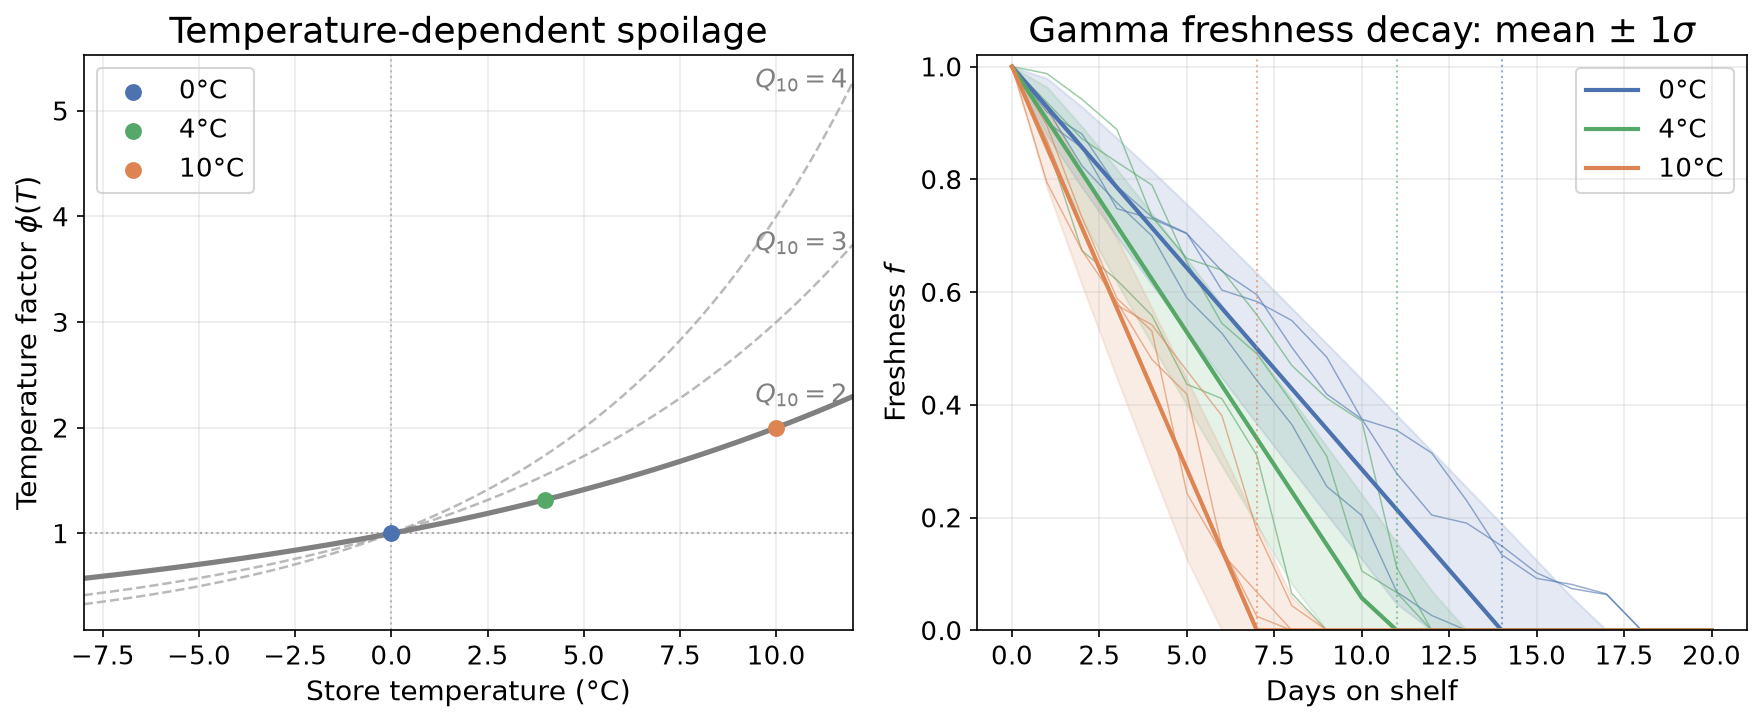

,t_store_c,phi,gamma_shape,theta,mean_delta_f_per_day,spoil_day
0,0,1.000000,2.000000,0.035714,0.071429,14
1,4,1.319508,2.639016,0.035714,0.094251,11
2,10,2.000000,4.000000,0.035714,0.142857,7


In [3]:
GAMMA_SHAPE = 2.0
ETA_REF = 14.0
Q10 = 2.0
T_REF_C = 0.0
Q10_CURVES = [2.0, 3.0, 4.0]

def store_temp_factor(t_store_c, q10=Q10):
    return max(1.01, q10) ** ((t_store_c - T_REF_C) / 10)

def gamma_decrement_stats(t_store_c, q10=Q10):
    theta = 1.0 / (GAMMA_SHAPE * ETA_REF)
    phi = store_temp_factor(t_store_c, q10)
    shape = GAMMA_SHAPE * phi
    return shape, theta, phi, shape * theta

def envelope(t_store_c, start_f=1.0, days_to_plot=20, q10=Q10):
    shape, theta, phi, mean_delta = gamma_decrement_stats(t_store_c, q10)
    spoil_day = int(np.ceil(start_f / mean_delta))
    days = np.arange(0, days_to_plot + 1)
    mean = start_f - days * mean_delta
    std = np.where(days == 0, 0.0, theta * np.sqrt(days * shape))
    lower = np.clip(mean - std, 0, 1)
    upper = np.clip(mean + std, 0, 1)
    return days, np.clip(mean, 0, None), lower, upper, shape, theta, spoil_day

def realization(t_store_c, rng, start_f=1.0, max_days=60, q10=Q10):
    shape, theta, _phi, _mean_delta = gamma_decrement_stats(t_store_c, q10)
    f = start_f
    days, fs = [0], [f]
    for day in range(1, max_days + 1):
        f = max(0.0, f - rng.gamma(shape, theta))
        days.append(day)
        fs.append(f)
        if f <= 0.0:
            break
    return np.array(days), np.array(fs)

rng = np.random.default_rng(42)
N_REALIZATIONS = 3

temps = [(0, BLUE), (4, GREEN), (10, ORANGE)]

fig, axes = plt.subplots(1, 2, figsize=blog_figsize(0.42))  # match demand chart height

# Left: φ(T) for several Q10 values; markers only on the active Q10=2 curve
ax_phi = axes[0]
t_grid = np.linspace(T_REF_C - 8, T_REF_C + 12, 200)
for q10_curve in Q10_CURVES:
    phi_grid = store_temp_factor(t_grid, q10_curve)
    active = q10_curve == Q10
    ax_phi.plot(
        t_grid,
        phi_grid,
        color="gray",
        linewidth=2.5 if active else 1.2,
        linestyle="-" if active else "--",
        alpha=1.0 if active else 0.55,
        zorder=2 if active else 1,
    )
    ax_phi.text(
        t_grid[-1] - 0.15,
        phi_grid[-1],
        rf"$Q_{{10}}={q10_curve:g}$",
        ha="right",
        va="center",
        fontsize=plt.rcParams["legend.fontsize"],
        color="gray",
    )
ax_phi.axhline(1.0, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax_phi.axvline(T_REF_C, color="gray", linestyle=":", linewidth=1, alpha=0.5)
for t_store, color in temps:
    phi = store_temp_factor(t_store, Q10)
    ax_phi.scatter([t_store], [phi], color=color, s=50, zorder=3, label=f"{t_store}°C")
ax_phi.set_xlim(T_REF_C - 8, T_REF_C + 12)
ax_phi.set_xlabel("Store temperature (°C)")
ax_phi.set_ylabel(r"Temperature factor $\phi(T)$")
ax_phi.set_title(r"Temperature-dependent spoilage")
ax_phi.legend(loc="upper left")

# Right: gamma freshness decay (mean ± 1σ envelope + sample paths)
ax = axes[1]
for t_store, color in temps:
    days, mean, lower, upper, _shape, _theta, spoil_day = envelope(t_store)
    ax.fill_between(days, lower, upper, color=color, alpha=0.15)
    for _ in range(N_REALIZATIONS):
        r_days, r_fs = realization(t_store, rng)
        ax.plot(r_days, r_fs, color=color, linewidth=0.7, alpha=0.6, zorder=1)
    ax.plot(days, mean, color=color, linewidth=2, zorder=2, label=f"{t_store}°C")
    ax.axvline(spoil_day, color=color, linestyle=":", linewidth=1, alpha=0.6)

ax.set_xlabel("Days on shelf")
ax.set_ylabel("Freshness $f$")
ax.set_ylim(0, 1.02)
ax.set_title(r"Gamma freshness decay: mean $\pm$ 1$\sigma$")
ax.legend(loc="upper right")
fig.tight_layout()
save_blog_fig(fig, FIG_DIR / BLOG_FIG_GAMMA)
plt.show()

_gamma_rows = []
for t_store, _color in temps:
    shape, theta, phi, mean_delta = gamma_decrement_stats(t_store)
    _days, _mean, _lower, _upper, _s, _th, spoil_day = envelope(t_store)
    _gamma_rows.append({
        "t_store_c": t_store,
        "phi": phi,
        "gamma_shape": shape,
        "theta": theta,
        "mean_delta_f_per_day": mean_delta,
        "spoil_day": spoil_day,
    })
display(pd.DataFrame(_gamma_rows))


### Delivery conditions — arrival freshness and transit temperature

**Left:** six measured Abdella pallet temperature paths vs the production
`truth_transit_trace` generative model (embedded `abdella_mix`, ρ=0.08, N=2000 envelope,
seed 980_001). Each model sample trace gets a distinct orange hue.

**Right:** production arrival-freshness distribution (`abdella_mix` corridor mixture) from
`t163_phase1_realism_diag` against the target band and industry-anchor reference line.

**Note:** Rust diagnostics are cached under `notebooks/outputs/article_figures/` as JSON.
Set `FORCE_RECOMPUTE = True` in the setup cell to ignore caches and rebuild via `cargo`.

In [4]:
from blueberries_voi.model.abdella import load_abdella_shipments


def cargo_example(name: str) -> str:
    cmd = ["cargo", "run", "-p", "voi_core", "--release", "--example", name]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
    elapsed = time.perf_counter() - t0
    if proc.returncode != 0:
        print(proc.stdout[-4000:])
        print(proc.stderr[-4000:])
        raise RuntimeError(f"{name} failed (exit {proc.returncode})")
    print(f"{name}: {elapsed:.1f}s")
    return proc.stdout


diag = load_cached_json(COLD_CHAIN_DIAG_JSON, label="cold_chain_diag")
if diag is None:
    diag = json.loads(cargo_example("t163_phase1_realism_diag"))
    save_results_json(diag, COLD_CHAIN_DIAG_JSON, label="cold_chain_diag")

prod_truth = diag["final_production_default"]
samples = np.array(prod_truth["samples"])
band = (0.6, 0.9)

transit_payload = load_cached_json(TRANSIT_TRACES_JSON, label="transit_traces")
if transit_payload is None:
    transit_payload = json.loads(cargo_example("article_transit_traces"))
    save_results_json(transit_payload, TRANSIT_TRACES_JSON, label="transit_traces")

abdella_shipments = load_abdella_shipments(REPO_ROOT / "data" / "abdella")

u = np.asarray(transit_payload["u_grid"], dtype=float)
env_mean = np.asarray(transit_payload["envelope_mean_c"], dtype=float)
env_std = np.asarray(transit_payload["envelope_std_c"], dtype=float)
median_d = float(np.median([s.duration_d for s in abdella_shipments]))
env_days = u * median_d
TRACE_LW = 1.4

print(
    f"freshness n={prod_truth['n']}  mean={prod_truth['mean']:.3f}  sd={prod_truth['sd']:.3f}  "
    f"p50={prod_truth['p50']:.3f}  pct in [0.6,0.9]={prod_truth['pct_60_90']:.1f}%"
)
print(
    f"transit corridor={transit_payload['corridor']}  ρ={transit_payload['rho']}  "
    f"q10={transit_payload['q10']}  η_ref={transit_payload['reference_life_days']}  "
    f"seed={transit_payload['seed']}  median Abdella d={median_d:.2f} d  "
    f"envelope N={transit_payload['n_envelope']}"
)


[cold_chain_diag] loaded from t163_phase1_realism_diag.json (skipping cargo)
[transit_traces] loaded from article_transit_traces.json (skipping cargo)
freshness n=2000  mean=0.710  sd=0.153  p50=0.802  pct in [0.6,0.9]=64.7%
transit corridor=abdella_mix  ρ=0.08  q10=2.0  η_ref=14.0  seed=980001  median Abdella d=4.98 d  envelope N=2000


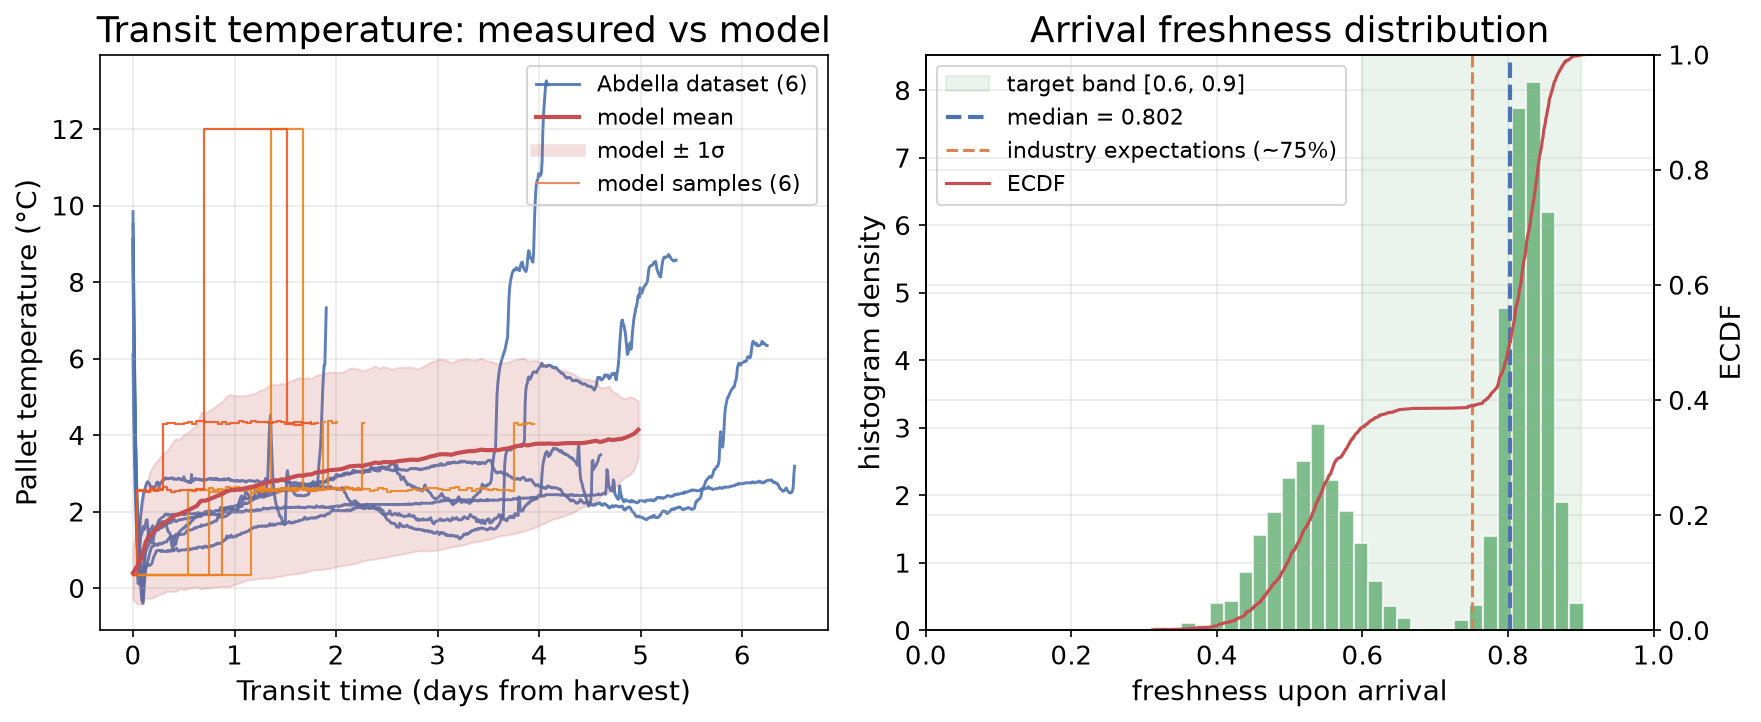

,n,mean,sd,p50,pct_in_0.6_0.9
0,2000,0.710189,0.153207,0.802413,64.7


,transit_day,model_mean_c,model_std_c
0,0.000000,0.401415,0.692179
1,0.041813,0.576165,0.993328
2,0.083625,0.798639,1.207928
3,0.125438,1.210117,1.457902
4,0.167250,1.386475,1.655841
...,...,...,...
115,4.808444,3.902749,1.074059
116,4.850257,3.937068,1.025307
117,4.892069,3.986255,1.018521
118,4.933882,4.038699,0.931903


,shipment,duration_d,n_points,temp_mean_c,temp_min_c,temp_max_c
0,0,4.604167,664,2.494471,0.314286,9.514286
1,1,1.902778,275,2.261070,0.111111,9.844444
2,2,6.243056,900,2.704753,-0.400000,8.888889
3,3,5.347222,771,2.963684,-0.344444,8.722222
4,4,6.513889,939,2.283259,0.155556,9.100000
5,5,4.083333,589,3.226292,0.022222,13.262500


In [5]:
import matplotlib.colors as mcolors

MODEL_SAMPLE_LW = TRACE_LW * 0.75

fig, (ax_trace, ax_hist) = plt.subplots(1, 2, figsize=blog_figsize(0.42))

# --- Left: transit temperature traces ---
for ship in abdella_shipments:
    ax_trace.plot(
        ship.times_d,
        ship.temps_c,
        color=BLUE,
        linewidth=TRACE_LW,
        alpha=0.9,
        zorder=1,
    )

ax_trace.fill_between(
    env_days,
    env_mean - env_std,
    env_mean + env_std,
    color=RED,
    alpha=0.18,
    zorder=2,
)
ax_trace.plot(env_days, env_mean, color=RED, linewidth=2.0, zorder=4)

orange_rng = np.random.default_rng(int(transit_payload["seed"]) + 99)
for trace in transit_payload["sample_traces"]:
    hue = float(orange_rng.uniform(0.04, 0.12))
    sample_color = mcolors.hsv_to_rgb((hue, 0.85, 0.92))
    ax_trace.plot(
        trace["times_d"],
        trace["temps_c"],
        color=sample_color,
        linewidth=MODEL_SAMPLE_LW,
        alpha=0.9,
        zorder=3,
    )

ax_trace.legend(
    handles=[
        Line2D([0], [0], color=BLUE, linewidth=TRACE_LW, alpha=0.9, label="Abdella dataset (6)"),
        Line2D([0], [0], color=RED, linewidth=2.0, label="model mean"),
        Line2D([0], [0], color=RED, linewidth=6, alpha=0.18, label="model ± 1σ"),
        Line2D([0], [0], color=ORANGE, linewidth=MODEL_SAMPLE_LW, alpha=0.9, label="model samples (6)"),
    ],
    loc="upper right",
    fontsize=plt.rcParams["legend.fontsize"] * 0.85,
)
ax_trace.set_xlabel("Transit time (days from harvest)")
ax_trace.set_ylabel("Pallet temperature (°C)")
ax_trace.set_title("Transit temperature: measured vs model")

# --- Right: arrival freshness distribution ---
ax_hist.axvspan(*band, color=GREEN, alpha=0.12, label="target band [0.6, 0.9]")
ax_hist.hist(
    samples,
    bins=30,
    density=True,
    color=GREEN,
    alpha=0.75,
    edgecolor="white",
)
sorted_s = np.sort(samples)
cdf_y = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
ax_hist2 = ax_hist.twinx()
ax_hist2.plot(sorted_s, cdf_y, color=RED, lw=1.5, label="ECDF")
ax_hist2.set_ylabel("ECDF")
ax_hist2.set_ylim(0, 1)
ax_hist.axvline(
    prod_truth["p50"],
    color=BLUE,
    lw=2,
    ls="--",
    label=f"median = {prod_truth['p50']:.3f}",
)
ax_hist.axvline(
    0.75,
    color=ORANGE,
    ls="--",
    lw=1.5,
    label="industry expectations (~75%)",
)
ax_hist.set_xlim(0, 1)
ax_hist.set_xlabel("freshness upon arrival")
ax_hist.set_ylabel("histogram density")
ax_hist.set_title("Arrival freshness distribution")
h1, l1 = ax_hist.get_legend_handles_labels()
h2, l2 = ax_hist2.get_legend_handles_labels()
ax_hist.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=plt.rcParams["legend.fontsize"] * 0.85)

fig.tight_layout()
save_blog_fig(fig, FIG_DIR / BLOG_FIG_COLD_CHAIN)
plt.show()

display(pd.DataFrame([{
    "n": prod_truth["n"],
    "mean": prod_truth["mean"],
    "sd": prod_truth["sd"],
    "p50": prod_truth["p50"],
    "pct_in_0.6_0.9": prod_truth["pct_60_90"],
}]))
display(pd.DataFrame({
    "transit_day": env_days,
    "model_mean_c": env_mean,
    "model_std_c": env_std,
}))
_abdella_rows = [
    {
        "shipment": i,
        "duration_d": float(ship.duration_d),
        "n_points": len(ship.times_d),
        "temp_mean_c": float(np.mean(ship.temps_c)),
        "temp_min_c": float(np.min(ship.temps_c)),
        "temp_max_c": float(np.max(ship.temps_c)),
    }
    for i, ship in enumerate(abdella_shipments)
]
display(pd.DataFrame(_abdella_rows))


### Demand model

**Left:** daily demand over the Mar–Jun calendar with the fitted mean and a μ ± 1σ envelope.
**Right:** one example day (Sunday, week 9) — histogram of observed demand vs the fitted
negative-binomial model.

Requires FreshNet parquet under `.data/freshnet/` (see notebook 15). If missing:
`uv sync --extra freshnet && uv run python scripts/fit_freshnet_demand.py`.

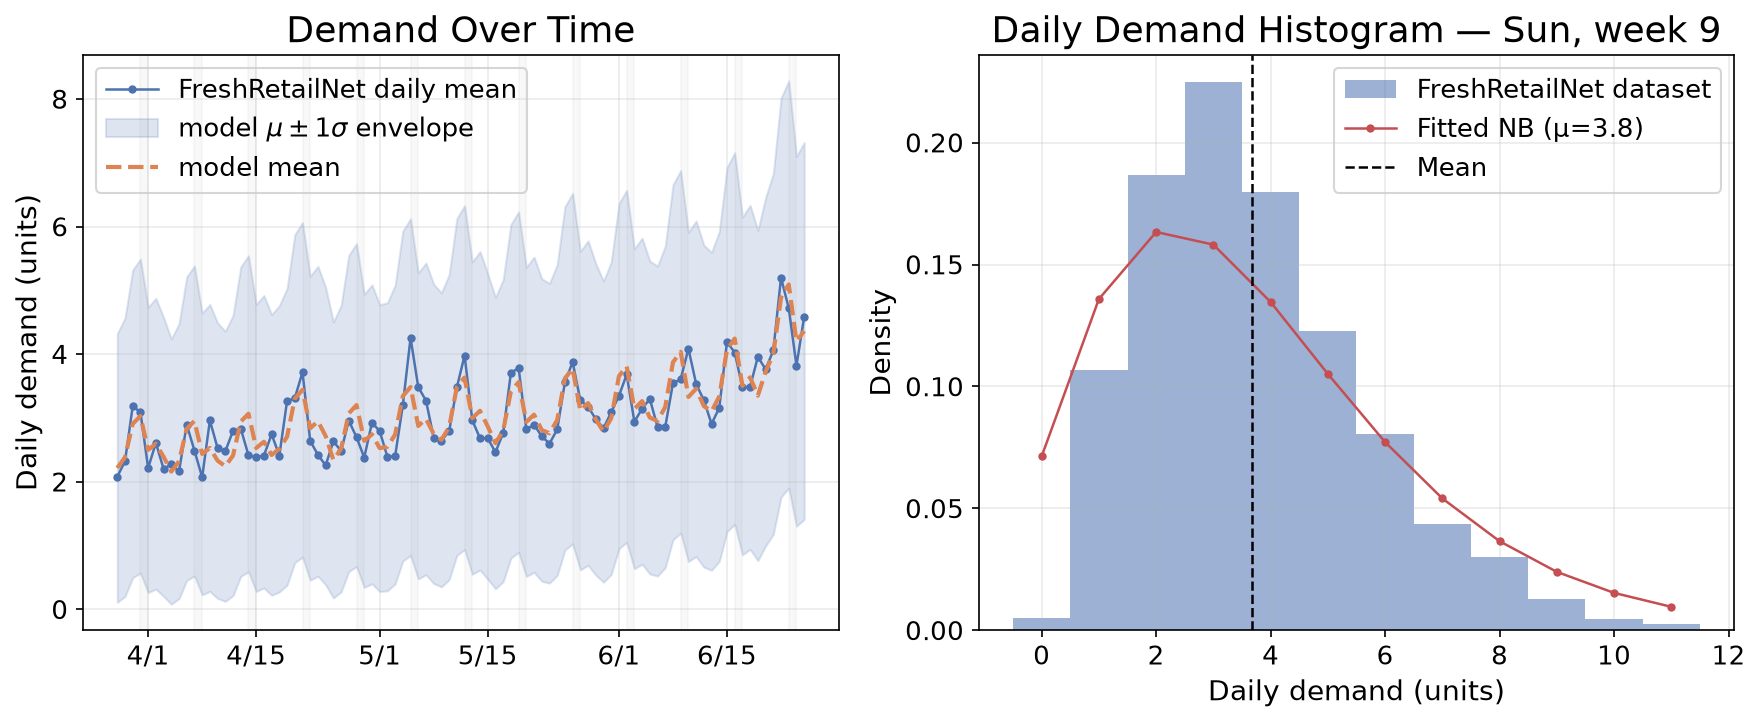

parquet: /home/oliver/blog/blueberries-voi/.data/freshnet/data/train.parquet
corr(pooled daily mean, μ): 0.896
PMF cell: Sun, week_index=9, n=2367 store×SKU rows


,dt,n,obs_mean,mu_model,sigma,lower,upper
0,2024-03-28,1290,2.079240,2.215207,2.104855,0.110352,4.320062
1,2024-03-29,1990,2.319437,2.382233,2.182766,0.199467,4.564998
2,2024-03-30,1860,3.181554,2.906949,2.411203,0.495747,5.318152
3,2024-03-31,1321,3.093210,3.029790,2.461621,0.568169,5.491411
4,2024-04-01,1591,2.214393,2.499026,2.235632,0.263394,4.734659
...,...,...,...,...,...,...,...
85,2024-06-21,2048,4.058311,4.004170,2.829901,1.174269,6.834071
86,2024-06-22,1208,5.198087,4.886139,3.126064,1.760075,8.012203
87,2024-06-23,1205,4.720747,5.092615,3.191431,1.901184,8.284045
88,2024-06-24,1641,3.820956,4.200482,2.898442,1.302040,7.098923


,dow,week_index,n,obs_mean,mu_model,nb_r,nb_p
0,Sun,9,2367,3.681199,3.809425,3.809425,0.5


In [6]:
import sys
from datetime import timedelta

import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter


_SCRIPTS = REPO_ROOT / "scripts"
if str(_SCRIPTS) not in sys.path:
    sys.path.insert(0, str(_SCRIPTS))

from fit_freshnet_demand import (  # noqa: E402
    _CENSOR_MAX_STOCK_HOURS,
    _fit_profile,
    _select_skus,
)

DEMAND_VM = 2.0
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
_PARQUET_CANDIDATES = [
    REPO_ROOT / ".data" / "freshnet" / "data" / "train.parquet",
    REPO_ROOT.parent / ".data" / "freshnet" / "data" / "train.parquet",
]
PARQUET_PATH = next((p for p in _PARQUET_CANDIDATES if p.is_file()), None)
if PARQUET_PATH is None:
    raise FileNotFoundError(
        "FreshNet parquet not found. Run: uv sync --extra freshnet && "
        "uv run python scripts/fit_freshnet_demand.py"
    )

_COLS = [
    "product_id",
    "management_group_id",
    "dt",
    "sale_amount",
    "stock_hour6_22_cnt",
]
_df = pd.read_parquet(PARQUET_PATH, columns=_COLS)
_sku_ids = _select_skus(_df)
_profile, _ = _fit_profile(_df, _sku_ids)
_sub = _df[
    _df["product_id"].isin(_sku_ids)
    & (_df["stock_hour6_22_cnt"] <= _CENSOR_MAX_STOCK_HOURS)
].copy()
_sub["dt"] = pd.to_datetime(_sub["dt"])
_sub["dow"] = _sub["dt"].dt.dayofweek.astype(int)
_t0 = _sub["dt"].min().normalize()
_sub["week_index"] = ((_sub["dt"] - _t0).dt.days // 7).astype(int)
_grand_mean = float(_sub["sale_amount"].mean())

_cell = (
    _sub.groupby(["dow", "week_index"])["sale_amount"]
    .agg(n="count", mean="mean")
    .reset_index()
)


def _model_mu_data_units(row: pd.Series) -> float:
    return float(
        _grand_mean
        * _profile["dow_factors"][int(row.dow)]
        * _profile["week_factors"][int(row.week_index)]
    )


def _nb_r_p(mu: float, vm: float = DEMAND_VM) -> tuple[float, float]:
    r = mu / (vm - 1.0)
    p = r / (r + mu)
    return r, p


def _nb_sigma(mu: float, vm: float = DEMAND_VM) -> float:
    """NB standard deviation under ModelParams convention (σ² = μ × V/M)."""
    return float(np.sqrt(max(mu, 0.0) * vm))


# --- Left: Plot G + NB μ ± 1σ envelope ---
daily = (
    _sub.groupby("dt")
    .agg(obs_mean=("sale_amount", "mean"), n=("sale_amount", "size"))
    .reset_index()
)
daily["dow"] = daily["dt"].dt.dayofweek
daily["week_index"] = ((daily["dt"] - _t0).dt.days // 7).astype(int)
daily["mu_model"] = daily.apply(_model_mu_data_units, axis=1)
daily["sigma"] = daily["mu_model"].map(_nb_sigma)
daily["lower"] = np.maximum(0.0, daily["mu_model"] - daily["sigma"])
daily["upper"] = daily["mu_model"] + daily["sigma"]

# --- Right: Plot F — Sunday, week 9 (notebook 15 median-n example) ---
_PM_F_DOW = 6  # Sunday (Mon=0)
_PM_F_WEEK = 9
_pm_row = _cell[(_cell["dow"] == _PM_F_DOW) & (_cell["week_index"] == _PM_F_WEEK)].iloc[0]
assert int(_pm_row.n) == 2367, f"expected n=2367, got {int(_pm_row.n)}"
_pm_mu = _model_mu_data_units(_pm_row)
_pm_mask = (_sub["dow"] == _PM_F_DOW) & (_sub["week_index"] == _PM_F_WEEK)
_pm_obs = _sub.loc[_pm_mask, "sale_amount"]
_r, _p = _nb_r_p(_pm_mu)
_y_max = int(max(_pm_row["mean"] * 3, _sub["sale_amount"].quantile(0.995)))
_ys = np.arange(0, _y_max + 1)
_pmf = stats.nbinom.pmf(_ys, _r, _p)

fig, axes = plt.subplots(1, 2, figsize=blog_figsize(0.42))  # was 14×4.2

ax0 = axes[0]
ax0.plot(daily["dt"], daily["obs_mean"], "o-", ms=3, lw=1.2, color=BLUE, label="FreshRetailNet daily mean")
ax0.fill_between(
    daily["dt"],
    daily["lower"],
    daily["upper"],
    color=BLUE,
    alpha=0.18,
    label=r"model $\mu \pm 1\sigma$ envelope",
)
ax0.plot(daily["dt"], daily["mu_model"], "--", lw=2, color=ORANGE, label="model mean")
for dt in daily["dt"]:
    if dt.dayofweek == 6:
        ax0.axvspan(dt, dt + timedelta(days=1), color="grey", alpha=0.05)
ax0.set_ylabel("Daily demand (units)")
ax0.set_title("Demand Over Time")
ax0.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{mdates.num2date(x).month}/{mdates.num2date(x).day}")
)
ax0.legend(loc="upper left")

ax1 = axes[1]
_bins = np.arange(-0.5, _y_max + 1.5, 1)
ax1.hist(_pm_obs, bins=_bins, density=True, alpha=0.55, color=BLUE, label="FreshRetailNet dataset")
ax1.plot(_ys, _pmf, color=RED, marker="o", ms=3, lw=1.2, label=f"Fitted NB (μ={_pm_mu:.1f})")
ax1.axvline(_pm_row["mean"], color="k", ls="--", lw=1.2, label="Mean")
ax1.set_xlabel("Daily demand (units)")
ax1.set_ylabel("Density")
ax1.set_title(f"Daily Demand Histogram — {DOW_LABELS[_PM_F_DOW]}, week {_PM_F_WEEK}")
ax1.legend()

fig.tight_layout()
save_blog_fig(fig, FIG_DIR / BLOG_FIG_DEMAND)
plt.show()

print(f"parquet: {PARQUET_PATH}")
print(f"corr(pooled daily mean, μ): {daily['obs_mean'].corr(daily['mu_model']):.3f}")
print(
    f"PMF cell: {DOW_LABELS[_PM_F_DOW]}, week_index={_PM_F_WEEK}, "
    f"n={int(_pm_row.n)} store×SKU rows"
)

display(daily[["dt", "n", "obs_mean", "mu_model", "sigma", "lower", "upper"]])
display(pd.DataFrame([{
    "dow": DOW_LABELS[_PM_F_DOW],
    "week_index": _PM_F_WEEK,
    "n": int(_pm_row.n),
    "obs_mean": float(_pm_row["mean"]),
    "mu_model": _pm_mu,
    "nb_r": _r,
    "nb_p": _p,
}]))


## The controller

**Note on which controller these figures use:** `channel_joint.run_seed_channel_joint`
(the pipeline behind every closed-loop chart below) hardcodes `policy="damped_sw"`
via `_damped_sw_act_kw` — regardless of which alpha table entry is loaded. Every figure
in this notebook is `damped_sw`, matching the post's existing controller formula
$q = \mathrm{caseRound}(\rho \cdot \max(0,\ F^{-1}(\alpha) - \tilde I))$ — no rewrite of that
paragraph needed. (`sla_pb`/`sla_mc` were explored separately; `sla_mc` showed a real
MC-convergence instability and was dropped from consideration for this post.)

**Note on `L` (lot-slot wire dimension):** figures below were regenerated at `L=50`
(previously `L=3`). `belief_flat_from_unit_bank` (`crates/voi_core/src/belief_flat.rs`)
exports only the newest `L` lot segments to the belief wire — LGTIN populates far more
distinct segments per delivery than UPC does for the same physical shipment (LGTIN
pushes each sub-lot as its own segment; UPC merges a whole delivery into one mixture
cohort), so a small `L` truncated LGTIN's *oldest* live inventory far more often than
UPC's. That produced a spurious LGTIN-looks-worse-than-UPC signal in both the freshness
$W_1$ metric and a signed-bias check (LGTIN's belief skewed systematically "fresher than
truth"): missing the stale tail shifts the reported distribution younger. A benchmark
across `L=3,10,20,30` under both `damped_sw` and `sla_pb` found no meaningful runtime
cost difference between `L=10/20/30` (all comfortably inside the 500ms/1000ms autopilot
budgets) — `sla_pb` tail latency was actually *worse* at `L=3` than at any larger `L`.
`DEFAULT_L_DIM` is now `50` in `crates/voi_core/src/params.rs` (Studio's real default,
previously `10` — the `L=3` used throughout this notebook's earlier runs came from a
notebook/experiment convenience override in `profit_session_config`, not from Studio
itself), and `profit_session_config`'s explicit `"L": 3` override has been raised to
match. Rebuilt: `cargo build --release`, `maturin develop --release`, and the Studio
WASM bundle (`scripts/build-wasm.sh`) all reflect `L=50` as of this run.

**Controller values:** each of the 12 factorial channels uses its **own
independently Ax-tuned** `(alpha, rho)`
(`notebooks/damped_sw_controller_tuning.ipynb`'s per-channel
section, `outputs/damped_sw_alpha_bo_per_channel.json`) — each tuned against
its own real closed-loop `run_seed_channel_joint` evaluation (genuine
particle-filter belief at `filter_n=200`, not the oracle belief the shared
retune above uses). This is the textbook-correct way to measure
value-of-information (`V*(info) = max_policy E[profit | info]` per
information set), and it's what actually recovers a monotonic profit signal:
forcing every channel through one shared policy (tried at several `(alpha,
rho)` choices earlier tonight) flattened profit even when belief accuracy
stayed cleanly monotonic. See
`.team/plans/2026-08-30-particle-filter-collapse-fix.md` for the full
investigation.

In [7]:
_PER_CHANNEL_JSON = REPO_ROOT / "outputs" / "damped_sw_alpha_bo_per_channel.json"
_per_channel = json.loads(_PER_CHANNEL_JSON.read_text())["per_channel"]

def channel_key(ch_kw):
    waste = "on" if ch_kw["scan_waste"] else "off"
    return f"{ch_kw['code_type']}|{waste}|{ch_kw['delivery_history']}"

def channel_alpha_rho(ch_kw):
    r = _per_channel[channel_key(ch_kw)]
    return float(r["alpha"]), float(r["rho"])

# Kept for reference / the appendix's fallback path only -- no longer used to
# drive the ladder or factorial, which now use each channel's own tuning.
ALPHA = 0.7437600021964654
RHO = 1.5938240528614713
print(f"Loaded per-channel controller values from {_PER_CHANNEL_JSON.name} "
      f"({len(_per_channel)} channels)")

_tuning_rows = []
for k in sorted(_per_channel):
    code, waste, delivery = k.split("|")
    r = _per_channel[k]
    _tuning_rows.append({
        "code_type": code,
        "waste": waste,
        "delivery": delivery,
        "alpha": float(r["alpha"]),
        "rho": float(r["rho"]),
        "profit": float(r["profit"]),
    })
tuning_df = pd.DataFrame(_tuning_rows)
display(tuning_df)


Loaded per-channel controller values from damped_sw_alpha_bo_per_channel.json (12 channels)


,code_type,waste,delivery,alpha,rho,profit
0,lgtin,off,none,0.807159,1.394629,1864.473333
1,lgtin,off,pack_date,0.844297,1.277746,1872.033333
2,lgtin,off,temperature_history,0.793295,1.296369,1857.500000
3,lgtin,on,none,0.695416,1.626026,1871.686667
4,lgtin,on,pack_date,0.781933,1.378201,1859.380000
5,lgtin,on,temperature_history,0.796061,1.374798,1865.313333
6,upc,off,none,0.653092,1.591172,1857.166667
7,upc,off,pack_date,0.830885,1.399428,1855.326667
8,upc,off,temperature_history,0.735492,1.462916,1851.233333
9,upc,on,none,0.789762,1.250511,1875.646667


## Results

### Belief error vs. profit — monotonic ladder

Grouped bar chart: belief \(W_1\) ratio and profit ratio vs. the "Books only" baseline,
95% CI (t-distribution, n=30 seeds).

**Methodology note — why two different simulation modes per rung:**
Running the real closed-loop controller per rung (`session.act()`) confounds filter
accuracy with the controller: a better-informed rung orders differently, which changes
its *actual* physical trajectory, so rungs stop being compared against a shared shelf
history. `notebooks/17_prelim_channel_ladder.ipynb` Part 1 avoids this via a **replay**
design — one truth trajectory per seed (fixed exogenous order schedule), replayed
through each rung's observation mask. We reproduce that design here (Tier: paired by
seed, not by exact episode) for the belief-accuracy numbers, while keeping the
profit numbers on the real closed loop (profit is inherently a closed-loop-only
concept — the controller must actually act to have a P&L).

In [8]:
# 30 seeds via a fixed RNG for reproducibility (was 8 hand-picked seeds).
SEEDS = tuple(int(s) for s in np.random.default_rng(2026).integers(0, 2**31 - 1, size=30))
N_BURN, N_SCORE = 2, 30
FILTER_N = 200  # Studio's real default (web/src/controls.ts)

LADDER = [
    ("Books only", {"code_type": "upc", "scan_waste": False, "delivery_history": "none"}),
    ("Scan waste on", {"code_type": "upc", "scan_waste": True, "delivery_history": "none"}),
    ("Pack date", {"code_type": "upc", "scan_waste": True, "delivery_history": "pack_date"}),
    ("LGTIN", {"code_type": "lgtin", "scan_waste": True, "delivery_history": "pack_date"}),
    ("Temp history", {"code_type": "lgtin", "scan_waste": True, "delivery_history": "temperature_history"}),
]
LADDER_ORDER = [label for label, _ in LADDER]

@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_ladder(seed, ladder, n_burn, n_score, filter_n, per_channel):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.channel_joint import run_seed_channel_joint
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.experiments.belief_accuracy import day_w1_error
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.simulator import EngineSession

    def key(ch_kw):
        waste = "on" if ch_kw["scan_waste"] else "off"
        return f"{ch_kw['code_type']}|{waste}|{ch_kw['delivery_history']}"

    baseline_kw = ladder[0][1]
    baseline_ch = ObsChannels(**baseline_kw)
    baseline_alpha = float(per_channel[key(baseline_kw)]["alpha"])
    baseline_rho = float(per_channel[key(baseline_kw)]["rho"])

    session = EngineSession()
    cfg = profit_session_config(n_rollout_paths=0, filter_n=filter_n)
    session.init(cfg, seed=seed)
    session.set_obs_channels(baseline_ch)
    act_kw = _damped_sw_act_kw(baseline_alpha, baseline_rho, n_rollout_paths=0)
    orders = []
    for _ in range(n_burn + n_score):
        delta = session.act(**act_kw)
        orders.append(int(delta["day"]["order_qty"]))

    rows = []
    for label, ch_kw in ladder:
        ch = ObsChannels(**ch_kw)
        rsession = EngineSession()
        rsession.init(cfg, seed=seed)
        rsession.set_obs_channels(ch)
        w1s = []
        for day_idx, q in enumerate(orders):
            d = rsession.step(q)
            if day_idx >= n_burn:
                w1 = day_w1_error(d)
                if w1 is not None:
                    w1s.append(w1)
        w1_mean = sum(w1s) / len(w1s) if w1s else float("nan")
        rung_alpha = float(per_channel[key(ch_kw)]["alpha"])
        rung_rho = float(per_channel[key(ch_kw)]["rho"])
        profit_row = run_seed_channel_joint(seed, ch, n_burn=n_burn, n_score=n_score,
                                             controller_alpha=rung_alpha, controller_rho=rung_rho,
                                             filter_n=filter_n)
        rows.append({"seed": seed, "rung": label, "profit": profit_row["profit"],
                     "freshness_w1_replay": w1_mean})
    return rows

_ladder_jobs = [(s, LADDER, N_BURN, N_SCORE, FILTER_N, _per_channel) for s in SEEDS]
ladder_df = load_cached_df(LADDER_CSV, label="ladder")
if ladder_df is None:
    ladder_rows = dispatch_modal(_process_seed_ladder, _ladder_jobs, "ladder")
    ladder_df = pd.DataFrame(ladder_rows)
    save_results_df(ladder_df, LADDER_CSV, label="ladder")
ladder_df.pivot_table(index="seed", columns="rung", values="freshness_w1_replay")[LADDER_ORDER]


[ladder] loaded 150 rows from ladder_replay_w1_profit.csv (skipping recompute)


rung,Books only,Scan waste on,Pack date,LGTIN,Temp history
seed,,,,,
56731231,0.090473,0.100785,0.051495,0.030244,0.020966
171429433,0.117967,0.117593,0.040316,0.032032,0.022995
211455622,0.077917,0.086395,0.047945,0.029468,0.019756
253438000,0.116355,0.122481,0.035124,0.030217,0.022338
355781144,0.116953,0.112541,0.043716,0.033734,0.034120
380863078,0.110189,0.122222,0.069572,0.034065,0.028679
384259585,0.095921,0.095917,0.059982,0.034860,0.021958
606662283,0.088760,0.093479,0.066707,0.031979,0.021950
640600314,0.167669,0.161113,0.060759,0.042122,0.026854


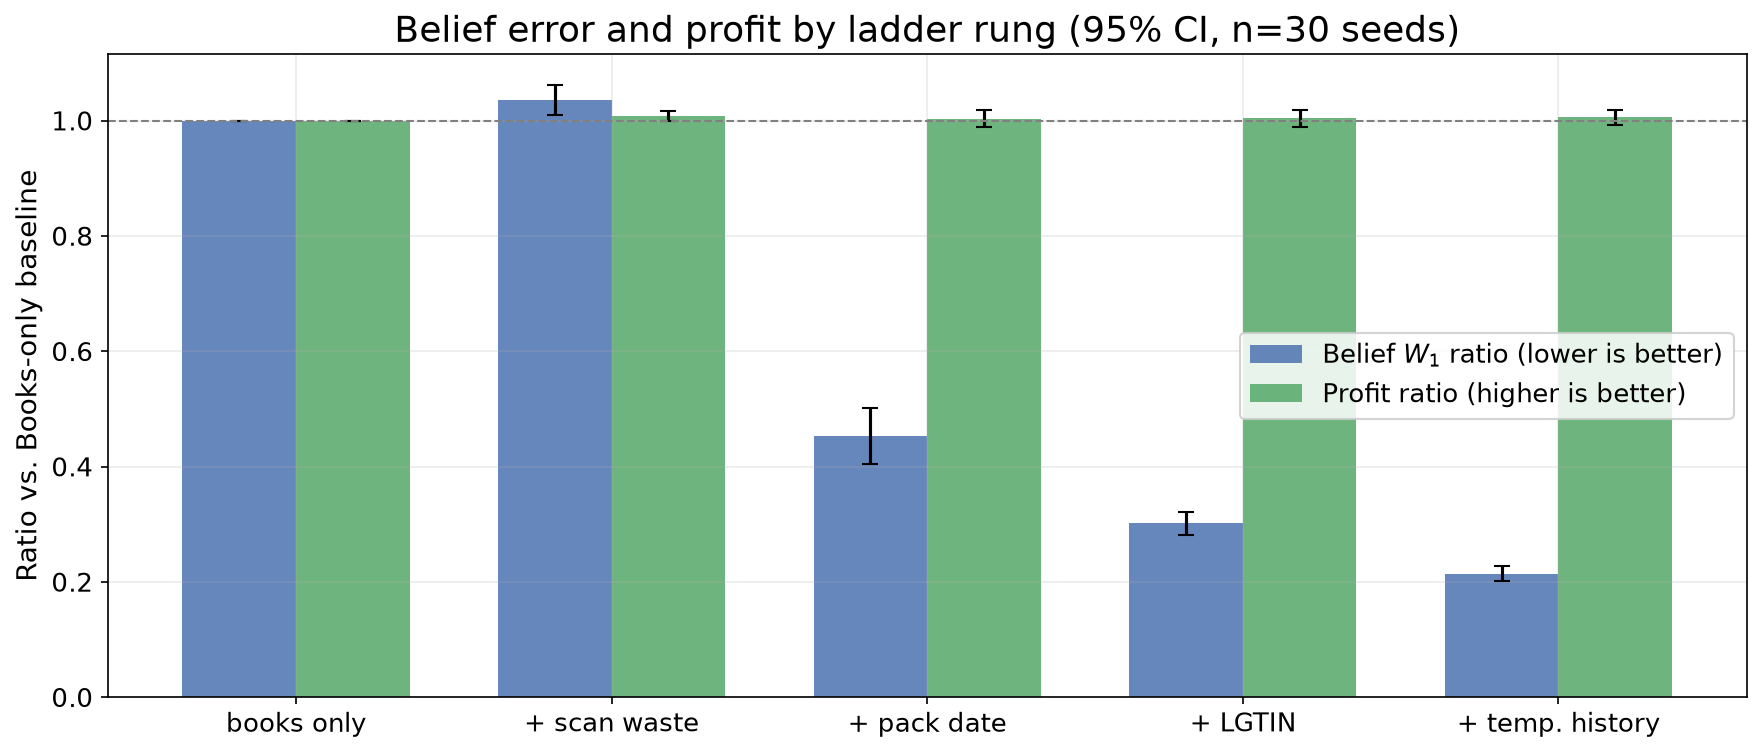

,belief_ratio_mean,belief_ratio_ci95,profit_ratio_mean,profit_ratio_ci95
rung,,,,
Books only,1.000000,0.000000,1.000000,0.000000
Scan waste on,1.035635,0.026257,1.008511,0.008349
Pack date,0.453047,0.047981,1.003350,0.014509
LGTIN,0.301351,0.019438,1.003718,0.014265
Temp history,0.214241,0.013000,1.005523,0.013532


In [9]:
piv_profit = ladder_df.pivot_table(index="seed", columns="rung", values="profit")[LADDER_ORDER]
piv_w1 = ladder_df.pivot_table(index="seed", columns="rung", values="freshness_w1_replay")[LADDER_ORDER]

profit_ratio = piv_profit.div(piv_profit["Books only"], axis=0)   # rung/base, higher = better
belief_ratio = piv_w1.div(piv_w1["Books only"], axis=0)           # rung/base, lower = better (raw W1)

n = len(piv_profit)
tcrit = stats.t.ppf(0.975, df=n - 1)

def mean_ci(frame):
    m = frame.mean()
    sem = frame.std(ddof=1) / np.sqrt(n)
    return m, tcrit * sem

profit_mean, profit_ci = mean_ci(profit_ratio)
belief_mean, belief_ci = mean_ci(belief_ratio)

LADDER_XLABELS = [
    "books only",
    "+ scan waste",
    "+ pack date",
    "+ LGTIN",
    "+ temp. history",
]

def ladder_grouped_bar_chart(
    belief_mean,
    belief_ci,
    profit_mean,
    profit_ci,
    *,
    title,
    out_name,
):
    fig, ax = plt.subplots(figsize=blog_figsize((5 / 8) * 0.7))  # ladder grouped bars
    n_rungs = len(LADDER_ORDER)
    x = np.arange(n_rungs)
    width = 0.36

    b_mean = belief_mean[LADDER_ORDER].to_numpy()
    b_err = belief_ci[LADDER_ORDER].to_numpy()
    p_mean = profit_mean[LADDER_ORDER].to_numpy()
    p_err = profit_ci[LADDER_ORDER].to_numpy()

    ax.bar(
        x - width / 2,
        b_mean,
        width,
        yerr=b_err,
        capsize=4,
        color=BLUE,
        alpha=0.85,
        label="Belief $W_1$ ratio (lower is better)",
    )
    ax.bar(
        x + width / 2,
        p_mean,
        width,
        yerr=p_err,
        capsize=4,
        color=GREEN,
        alpha=0.85,
        label="Profit ratio (higher is better)",
    )
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(LADDER_XLABELS)
    ax.set_ylabel("Ratio vs. Books-only baseline")
    ax.set_title(title)
    ax.legend(
        loc="center right",
        facecolor="white",
        framealpha=0.85,
        edgecolor="0.8",
    )
    fig.tight_layout()
    save_blog_fig(fig, FIG_DIR / out_name)
    plt.show()


ladder_grouped_bar_chart(
    belief_mean,
    belief_ci,
    profit_mean,
    profit_ci,
    title=f"Belief error and profit by ladder rung (95% CI, n={n} seeds)",
    out_name=BLOG_FIG_LADDER,
)

display(pd.DataFrame({
    "belief_ratio_mean": belief_mean[LADDER_ORDER],
    "belief_ratio_ci95": belief_ci[LADDER_ORDER],
    "profit_ratio_mean": profit_mean[LADDER_ORDER],
    "profit_ratio_ci95": profit_ci[LADDER_ORDER],
}))


### Belief accuracy vs. profit — all observation scenarios

Same ratio methodology, but over the full code-type × waste-scan × delivery-history
factorial (`channel_joint.all_obs_channels_product()`, 12 cells) rather than just the
5-rung monotonic path. **Profit** is closed-loop (per-channel `act()` with tuned
$(\alpha,\rho)$); **freshness $W_1$** uses shared-order replay (books-only order path,
### Belief accuracy vs. profit — all observation scenarios

Same ratio methodology, but over the full code-type × waste-scan × delivery-history
factorial (`channel_joint.all_obs_channels_product()`, 12 cells) rather than just the
5-rung monotonic path. **Profit** is closed-loop (per-channel `act()` with tuned
$(\alpha,\rho)$); **freshness $W_1$** uses shared-order replay (books-only order path,
filter-only replay per channel — same design as the ladder belief bars). A second figure
shows each channel's independently tuned $(\alpha,\rho)$. Legend grammar matches
`figures/channel_joint/profit_vs_mae_dist.png`: color = waste scan, marker =
delivery history, size = code type.


In [10]:
@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_factorial(seed, n_burn, n_score, filter_n, per_channel):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.channel_joint import all_obs_channels_product, run_seed_channel_joint

    def key(ch):
        waste = "on" if ch.scan_waste else "off"
        return f"{ch.code_type}|{waste}|{ch.delivery_history}"

    rows = []
    for ch in all_obs_channels_product():
        r = per_channel[key(ch)]
        rows.append(run_seed_channel_joint(seed, ch, n_burn=n_burn, n_score=n_score,
                                            controller_alpha=float(r["alpha"]), controller_rho=float(r["rho"]),
                                            filter_n=filter_n))
    return rows

_factorial_jobs = [(s, N_BURN, N_SCORE, FILTER_N, _per_channel) for s in SEEDS]
factorial_df = load_cached_df(FACTORIAL_CSV, label="factorial")
if factorial_df is None:
    factorial_rows = dispatch_modal(_process_seed_factorial, _factorial_jobs, "factorial")
    factorial_df = pd.DataFrame(factorial_rows)
    save_results_df(factorial_df, FACTORIAL_CSV, label="factorial")
factorial_df["combo"] = factorial_df["code_type"] + "|" + factorial_df["waste"] + "|" + factorial_df["delivery"]
print(f"rows: {len(factorial_df)}")

@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_factorial_replay(seed, n_burn, n_score, filter_n, per_channel):
    """Shared-order replay: baseline books-only act() path, filter-only replay per channel."""
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.belief_accuracy import day_w1_error
    from blueberries_voi.experiments.channel_joint import all_obs_channels_product
    from blueberries_voi.experiments.filter_accuracy import day_accuracy
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.simulator import EngineSession

    baseline = ObsChannels(code_type="upc", scan_waste=False, delivery_history="none")

    def key(ch):
        waste = "on" if ch.scan_waste else "off"
        return f"{ch.code_type}|{waste}|{ch.delivery_history}"

    br = per_channel[key(baseline)]
    cfg = profit_session_config(n_rollout_paths=0, filter_n=filter_n)
    act_kw = _damped_sw_act_kw(float(br["alpha"]), float(br["rho"]), n_rollout_paths=0)

    session = EngineSession()
    session.init(cfg, seed=seed)
    session.set_obs_channels(baseline)
    orders = []
    for _ in range(n_burn + n_score):
        orders.append(int(session.act(**act_kw)["day"]["order_qty"]))

    rows = []
    for ch in all_obs_channels_product():
        rsession = EngineSession()
        rsession.init(cfg, seed=seed)
        rsession.set_obs_channels(ch)
        w1s: list[float] = []
        counts: list[float] = []
        for day_idx, qty in enumerate(orders):
            delta = rsession.step(qty)
            if day_idx < n_burn:
                continue
            w1 = day_w1_error(delta)
            if w1 is not None:
                w1s.append(w1)
            acc = day_accuracy(delta, day_idx)
            if acc is not None:
                counts.append(acc.count_gap)
        rows.append(
            {
                "seed": seed,
                "code_type": ch.code_type,
                "waste": "on" if ch.scan_waste else "off",
                "delivery": ch.delivery_history,
                "freshness_w1": float(sum(w1s) / len(w1s)) if w1s else float("nan"),
                "count_mae": float(sum(counts) / len(counts)) if counts else float("nan"),
                "n_burn": int(n_burn),
                "n_score": int(n_score),
            }
        )
    return rows


_replay_jobs = [(s, N_BURN, N_SCORE, FILTER_N, _per_channel) for s in SEEDS]
factorial_replay_df = load_cached_df(FACTORIAL_REPLAY_CSV, label="factorial_replay")
if factorial_replay_df is None:
    factorial_replay_rows = dispatch_modal(_process_seed_factorial_replay, _replay_jobs, "factorial_replay")
    factorial_replay_df = pd.DataFrame(factorial_replay_rows)
    save_results_df(factorial_replay_df, FACTORIAL_REPLAY_CSV, label="factorial_replay")
factorial_replay_df["combo"] = (
    factorial_replay_df["code_type"]
    + "|"
    + factorial_replay_df["waste"]
    + "|"
    + factorial_replay_df["delivery"]
)
print(f"replay rows: {len(factorial_replay_df)}")


[factorial] loaded 360 rows from factorial_w1_profit.csv (skipping recompute)
rows: 360
[factorial_replay] loaded 360 rows from factorial_replay_w1_count.csv (skipping recompute)
replay rows: 360


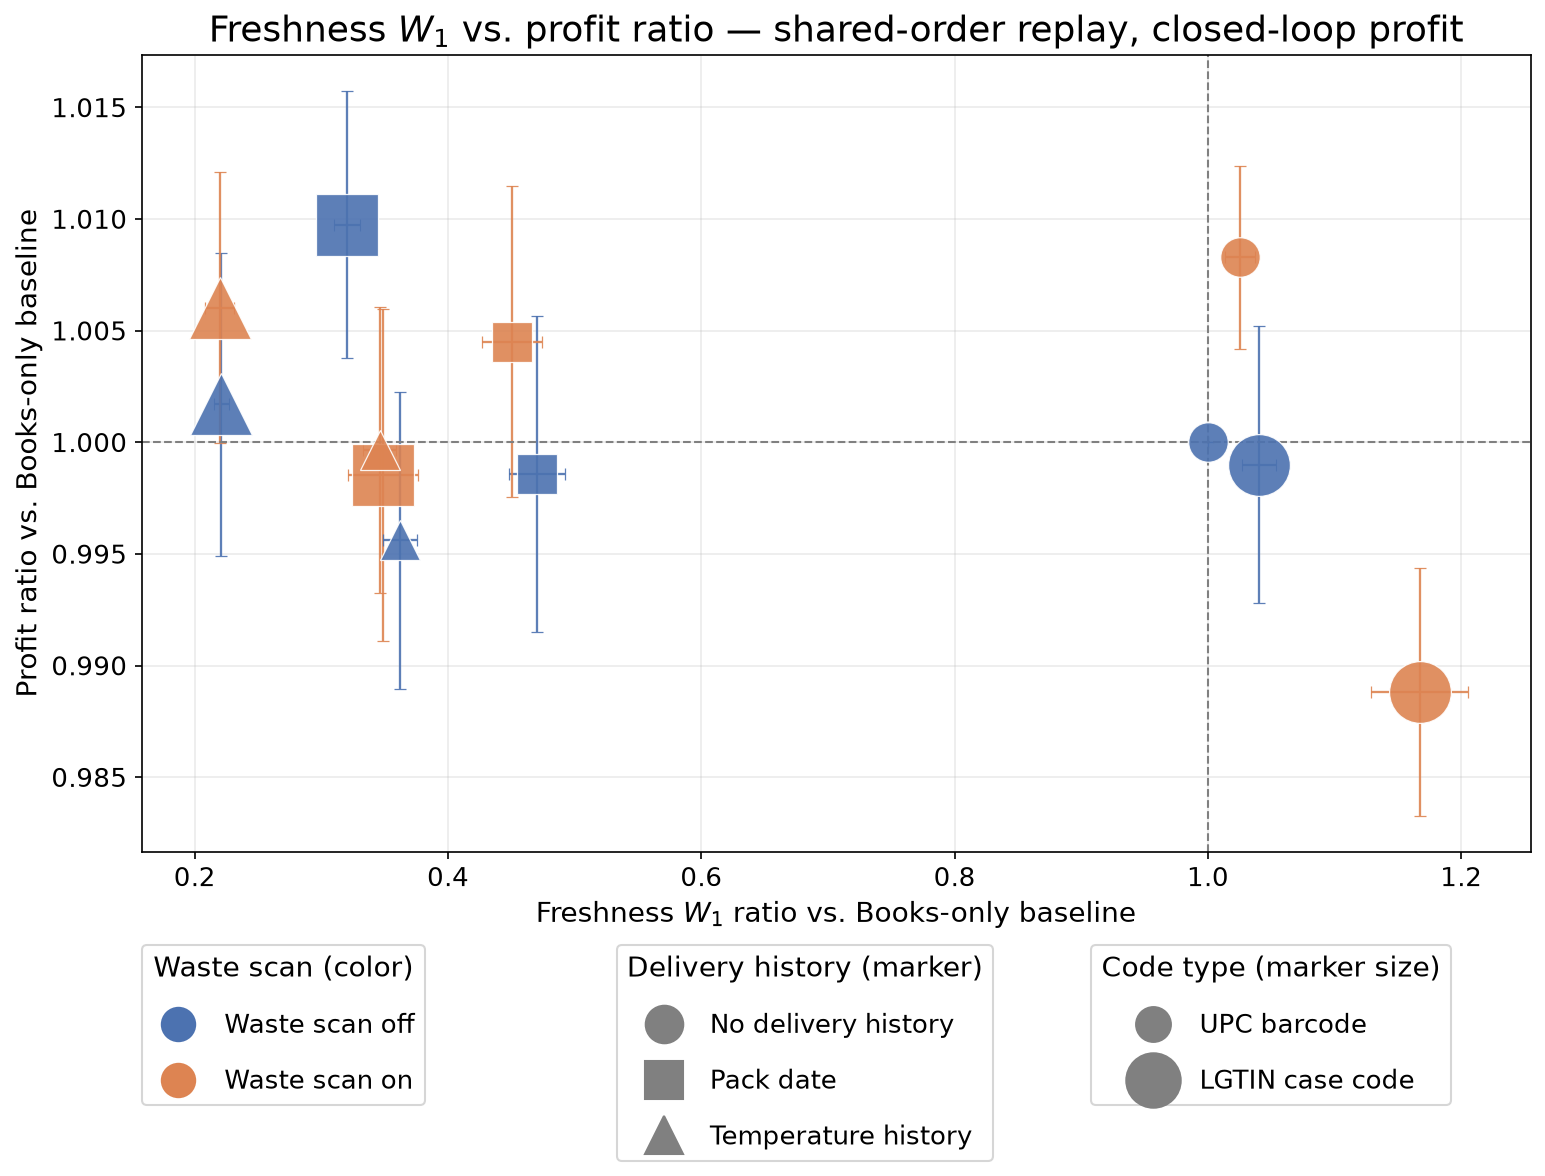

,combo,code_type,waste,delivery,w1_ratio_mean,w1_ratio_sem,profit_ratio_mean,profit_ratio_sem
0,lgtin|off|none,lgtin,off,none,1.040329,0.013343,0.998997,0.006212
1,lgtin|off|pack_date,lgtin,off,pack_date,0.320063,0.010208,1.009753,0.005984
2,lgtin|off|temperature_history,lgtin,off,temperature_history,0.220984,0.005822,1.001696,0.006778
3,lgtin|on|none,lgtin,on,none,1.167031,0.037972,0.988825,0.005551
4,lgtin|on|pack_date,lgtin,on,pack_date,0.348591,0.027728,0.998531,0.007418
5,lgtin|on|temperature_history,lgtin,on,temperature_history,0.219569,0.011481,1.006035,0.006087
6,upc|off|none,upc,off,none,1.000000,0.000000,1.000000,0.000000
7,upc|off|pack_date,upc,off,pack_date,0.469904,0.022164,0.998571,0.007066
8,upc|off|temperature_history,upc,off,temperature_history,0.362108,0.013152,0.995607,0.006655
9,upc|on|none,upc,on,none,1.025117,0.011690,1.008278,0.004103


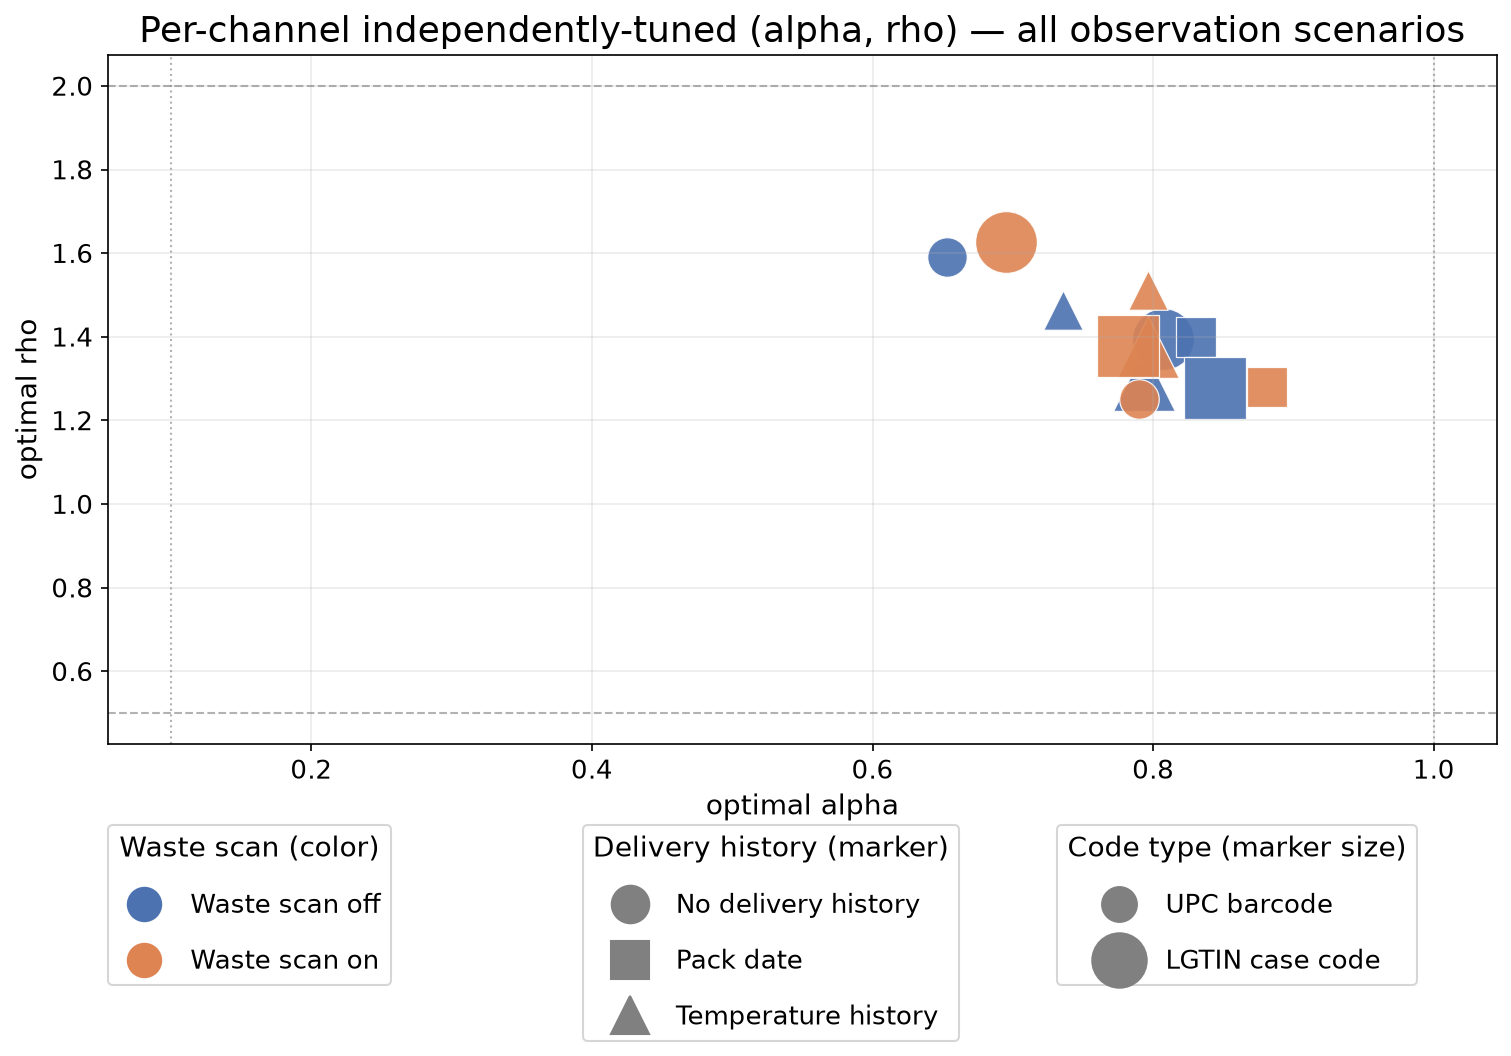

,code_type,waste,delivery,alpha,rho,profit
0,lgtin,off,none,0.807159,1.394629,1864.473333
1,lgtin,off,pack_date,0.844297,1.277746,1872.033333
2,lgtin,off,temperature_history,0.793295,1.296369,1857.500000
3,lgtin,on,none,0.695416,1.626026,1871.686667
4,lgtin,on,pack_date,0.781933,1.378201,1859.380000
5,lgtin,on,temperature_history,0.796061,1.374798,1865.313333
6,upc,off,none,0.653092,1.591172,1857.166667
7,upc,off,pack_date,0.830885,1.399428,1855.326667
8,upc,off,temperature_history,0.735492,1.462916,1851.233333
9,upc,on,none,0.789762,1.250511,1875.646667


In [11]:
baseline_key = "upc|off|none"
piv_fp = factorial_df.pivot_table(index="seed", columns="combo", values="profit")
f_ratio = piv_fp.div(piv_fp[baseline_key], axis=0)
f_y_mean, f_y_sem = f_ratio.mean(), f_ratio.std(ddof=1) / np.sqrt(len(f_ratio))

piv_fw1 = factorial_replay_df.pivot_table(index="seed", columns="combo", values="freshness_w1")
f_x_ratio = piv_fw1.div(piv_fw1[baseline_key], axis=0)
f_x_mean, f_x_sem = f_x_ratio.mean(), f_x_ratio.std(ddof=1) / np.sqrt(len(f_x_ratio))

combos = factorial_replay_df[["combo", "code_type", "waste", "delivery"]].drop_duplicates().set_index("combo")
waste_color = {"off": BLUE, "on": ORANGE}
delivery_marker = {"none": "o", "pack_date": "s", "temperature_history": "^"}

_FACTORIAL_SCATTER_ASPECT = 6.5 / 9
_FACTORIAL_PAD_ABOVE_LEGEND = 0.35
_MARKER_PT = 9 * BLOG_RETINA
_CODE_SIZE = {"upc": 90 * BLOG_RETINA**2, "lgtin": 220 * BLOG_RETINA**2}
_LEGEND_CODE_LABELSPACING = 1.15
_LEGEND_CODE_MARKERSCALE = 0.88

pc_combo_meta = {}
for k in _per_channel:
    code, waste, delivery = k.split("|")
    pc_combo_meta[k] = {"code_type": code, "waste": waste, "delivery": delivery}


def _factorial_legend_axes(fig, gs_row):
    gs_leg = gs_row.subgridspec(1, 3, wspace=0.08)
    axes = [fig.add_subplot(gs_leg[0, i]) for i in range(3)]
    for ax in axes:
        ax.set_axis_off()
    waste_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=_MARKER_PT, label=l)
        for c, l in [(BLUE, "Waste scan off"), (ORANGE, "Waste scan on")]
    ]
    delivery_handles = [
        Line2D([0], [0], marker=m, color="gray", linestyle="", markersize=_MARKER_PT, label=l)
        for m, l in [("o", "No delivery history"), ("s", "Pack date"), ("^", "Temperature history")]
    ]
    code_handles = [
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=np.sqrt(s), label=l)
        for s, l in [(_CODE_SIZE["upc"], "UPC barcode"), (_CODE_SIZE["lgtin"], "LGTIN case code")]
    ]
    legend_kw = dict(
        loc="upper left",
        frameon=True,
        borderaxespad=0,
        labelspacing=_LEGEND_CODE_LABELSPACING,
    )
    axes[0].legend(handles=waste_handles, title="Waste scan (color)", **legend_kw)
    axes[1].legend(handles=delivery_handles, title="Delivery history (marker)", **legend_kw)
    axes[2].legend(
        handles=code_handles,
        title="Code type (marker size)",
        markerscale=_LEGEND_CODE_MARKERSCALE,
        **legend_kw,
    )


# --- W1 vs profit ---
fig = plt.figure(figsize=blog_figsize(_FACTORIAL_SCATTER_ASPECT))
gs = fig.add_gridspec(
    3,
    1,
    height_ratios=[3, _FACTORIAL_PAD_ABOVE_LEGEND, 0.40],
    hspace=0.0,
)
ax = fig.add_subplot(gs[0])
_factorial_legend_axes(fig, gs[2])

for combo in f_y_mean.index:
    row = combos.loc[combo]
    ax.errorbar(
        f_x_mean[combo],
        f_y_mean[combo],
        xerr=f_x_sem[combo],
        yerr=f_y_sem[combo],
        fmt=delivery_marker[row["delivery"]],
        color=waste_color[row["waste"]],
        markersize=np.sqrt(_CODE_SIZE[row["code_type"]]),
        capsize=3,
        elinewidth=1.1,
        markeredgecolor="white",
        markeredgewidth=0.6,
        alpha=0.9,
    )

ax.set_xlabel("Freshness $W_1$ ratio vs. Books-only baseline")
ax.set_ylabel("Profit ratio vs. Books-only baseline")
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Freshness $W_1$ vs. profit ratio — shared-order replay, closed-loop profit")
save_blog_fig(fig, FIG_DIR / BLOG_FIG_FACTORIAL)
plt.show()

_factorial_w1_profit = pd.DataFrame({
    "combo": f_y_mean.index,
    "w1_ratio_mean": f_x_mean.reindex(f_y_mean.index).to_numpy(),
    "w1_ratio_sem": f_x_sem.reindex(f_y_mean.index).to_numpy(),
    "profit_ratio_mean": f_y_mean.to_numpy(),
    "profit_ratio_sem": f_y_sem.to_numpy(),
}).merge(combos.reset_index(), on="combo")
display(_factorial_w1_profit[
    ["combo", "code_type", "waste", "delivery",
     "w1_ratio_mean", "w1_ratio_sem", "profit_ratio_mean", "profit_ratio_sem"]
].sort_values("combo").reset_index(drop=True))

# --- controller tuning (alpha, rho) ---
fig = plt.figure(figsize=blog_figsize(BLOG_ASPECT_STANDARD))
gs = fig.add_gridspec(
    3,
    1,
    height_ratios=[3, _FACTORIAL_PAD_ABOVE_LEGEND, 0.40],
    hspace=0.0,
)
ax = fig.add_subplot(gs[0])
_factorial_legend_axes(fig, gs[2])

for combo, meta in pc_combo_meta.items():
    r = _per_channel[combo]
    ax.scatter(
        r["alpha"],
        r["rho"],
        marker=delivery_marker[meta["delivery"]],
        color=waste_color[meta["waste"]],
        s=_CODE_SIZE[meta["code_type"]],
        edgecolor="white",
        linewidth=0.6,
        alpha=0.9,
    )

ax.axvline(0.1, color="gray", ls=":", lw=1, alpha=0.6)
ax.axvline(0.9999, color="gray", ls=":", lw=1, alpha=0.6)
ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.6)
ax.axhline(2.0, color="gray", ls="--", lw=1, alpha=0.6)
ax.set_xlabel("optimal alpha")
ax.set_ylabel("optimal rho")
ax.set_title("Per-channel independently-tuned (alpha, rho) — all observation scenarios")
save_blog_fig(fig, FIG_DIR / BLOG_FIG_FACTORIAL_TUNING)
plt.show()

display(tuning_df)


### Freshness vs. count error — shared-order replay

Single-panel scatter over the same 12-cell factorial. Both axes use **shared-order
replay** (books-only order path, filter-only `step()` per channel). Ratios are
channel / books-only baseline, per seed, then mean ± SEM across seeds.

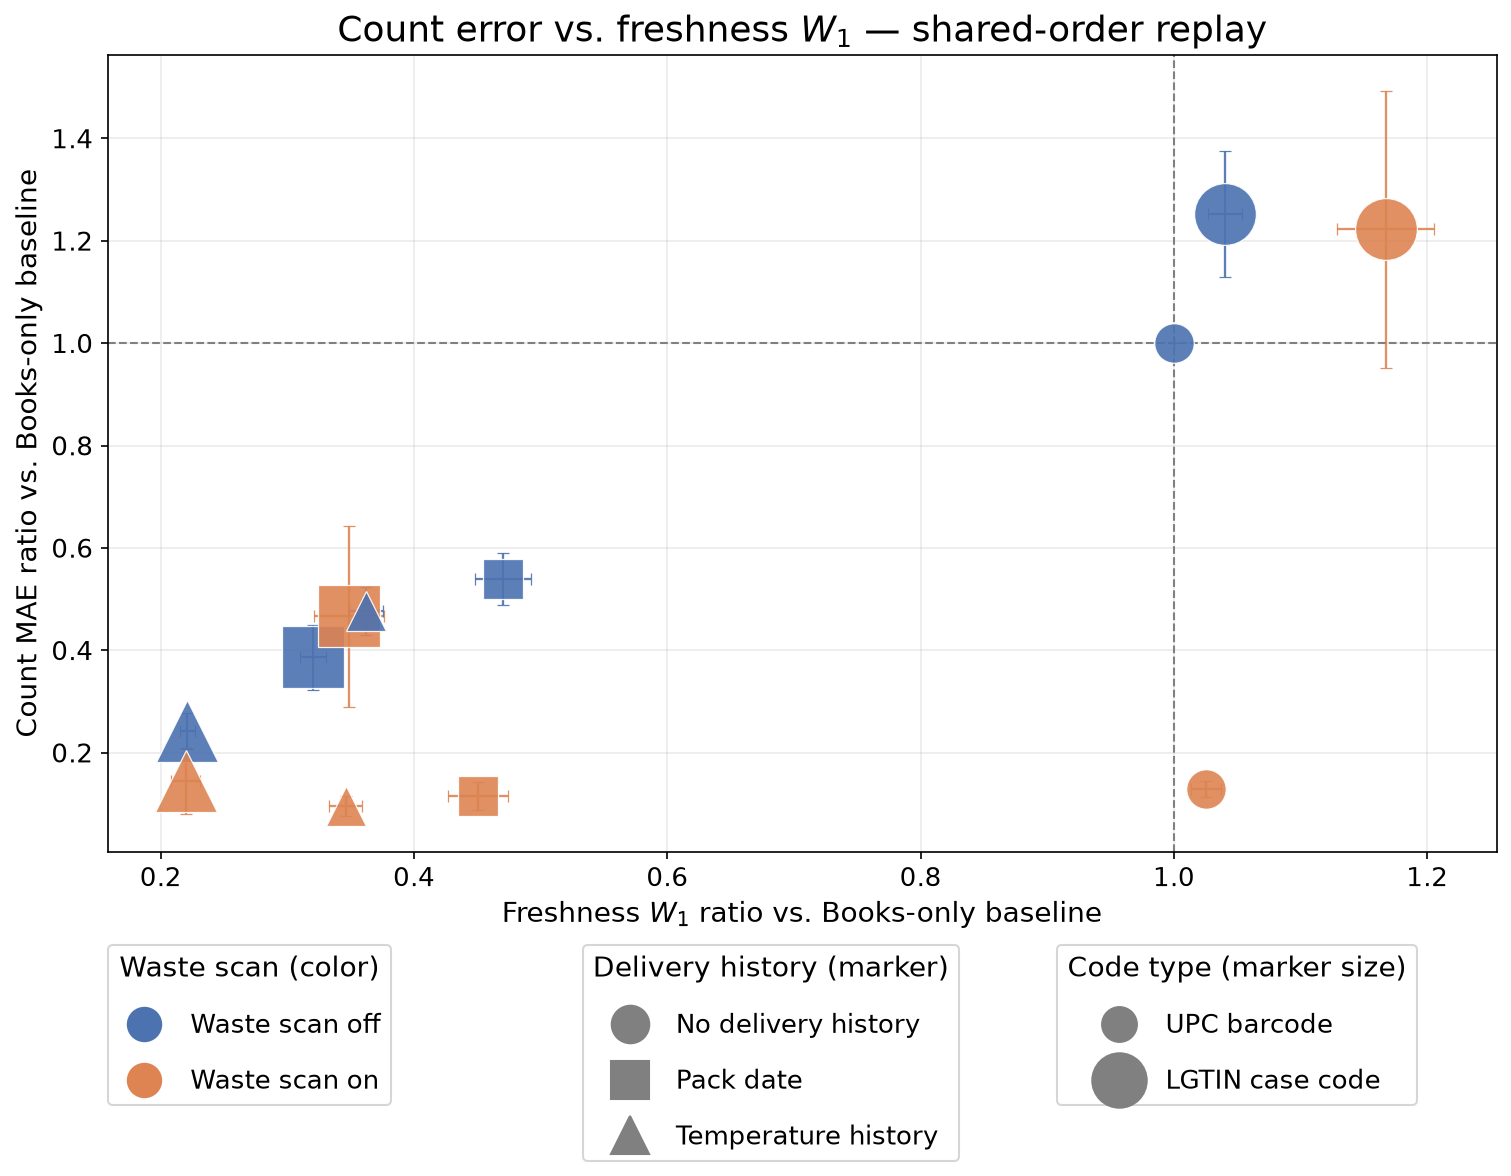

,combo,freshness_w1_ratio_mean,freshness_w1_ratio_sem,count_mae_ratio_mean,count_mae_ratio_sem,code_type,waste,delivery
0,lgtin|off|none,1.040329,0.013343,1.252119,0.123271,lgtin,off,none
1,lgtin|off|pack_date,0.320063,0.010208,0.386623,0.063489,lgtin,off,pack_date
2,lgtin|off|temperature_history,0.220984,0.005822,0.242741,0.034679,lgtin,off,temperature_history
3,lgtin|on|none,1.167031,0.037972,1.222290,0.270550,lgtin,on,none
4,lgtin|on|pack_date,0.348591,0.027728,0.466412,0.176652,lgtin,on,pack_date
5,lgtin|on|temperature_history,0.219569,0.011481,0.144813,0.065191,lgtin,on,temperature_history
6,upc|off|none,1.000000,0.000000,1.000000,0.000000,upc,off,none
7,upc|off|pack_date,0.469904,0.022164,0.539487,0.050372,upc,off,pack_date
8,upc|off|temperature_history,0.362108,0.013152,0.476219,0.046540,upc,off,temperature_history
9,upc|on|none,1.025117,0.011690,0.128161,0.015614,upc,on,none


In [12]:
_BASELINE_COMBO = "upc|off|none"
_FACTORIAL_SCATTER_ASPECT = 6.5 / 9
_FACTORIAL_SCATTER_PAD_ABOVE_LEGEND = 0.35  # plot → legend


def _factorial_ratio_means(df, *, value_col: str, baseline: str = _BASELINE_COMBO):
    piv = df.pivot_table(index="seed", columns="combo", values=value_col)
    ratio = piv.div(piv[baseline], axis=0)
    mean = ratio.mean()
    sem = ratio.std(ddof=1) / np.sqrt(len(ratio))
    return mean, sem


def plot_factorial_ratio_scatter(
    x_df,
    *,
    x_col: str,
    y_df,
    y_col: str,
    title: str,
    out_name: str,
    xlabel: str,
    ylabel: str,
) -> None:
    combos = x_df[["combo", "code_type", "waste", "delivery"]].drop_duplicates().set_index("combo")
    x_mean, x_sem = _factorial_ratio_means(x_df, value_col=x_col)
    y_mean, y_sem = _factorial_ratio_means(y_df, value_col=y_col)

    _marker_pt = 9 * BLOG_RETINA
    _code_size = {"upc": 90 * BLOG_RETINA**2, "lgtin": 220 * BLOG_RETINA**2}
    waste_color = {"off": BLUE, "on": ORANGE}
    delivery_marker = {"none": "o", "pack_date": "s", "temperature_history": "^"}

    fig = plt.figure(figsize=blog_figsize(_FACTORIAL_SCATTER_ASPECT))
    gs = fig.add_gridspec(
        3,
        1,
        height_ratios=[3, _FACTORIAL_SCATTER_PAD_ABOVE_LEGEND, 0.40],
        hspace=0.0,
    )
    ax = fig.add_subplot(gs[0])
    gs_leg = gs[2].subgridspec(1, 3, wspace=0.08)
    ax_l1, ax_l2, ax_l3 = (fig.add_subplot(gs_leg[0, i]) for i in range(3))
    for leg_ax in (ax_l1, ax_l2, ax_l3):
        leg_ax.set_axis_off()

    for combo in x_mean.index:
        row = combos.loc[combo]
        ax.errorbar(
            x_mean[combo],
            y_mean[combo],
            xerr=x_sem[combo],
            yerr=y_sem[combo],
            fmt=delivery_marker[row["delivery"]],
            color=waste_color[row["waste"]],
            markersize=np.sqrt(_code_size[row["code_type"]]),
            capsize=3,
            elinewidth=1.1,
            markeredgecolor="white",
            markeredgewidth=0.6,
            alpha=0.9,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axvline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(title)

    waste_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=_marker_pt, label=l)
        for c, l in [(BLUE, "Waste scan off"), (ORANGE, "Waste scan on")]
    ]
    delivery_handles = [
        Line2D([0], [0], marker=m, color="gray", linestyle="", markersize=_marker_pt, label=l)
        for m, l in [("o", "No delivery history"), ("s", "Pack date"), ("^", "Temperature history")]
    ]
    code_handles = [
        Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=np.sqrt(s), label=l)
        for s, l in [(_code_size["upc"], "UPC barcode"), (_code_size["lgtin"], "LGTIN case code")]
    ]
    _legend_kw = dict(
        loc="upper left",
        frameon=True,
        borderaxespad=0,
        labelspacing=1.15,
    )
    ax_l1.legend(handles=waste_handles, title="Waste scan (color)", **_legend_kw)
    ax_l2.legend(handles=delivery_handles, title="Delivery history (marker)", **_legend_kw)
    ax_l3.legend(
        handles=code_handles,
        title="Code type (marker size)",
        markerscale=0.88,
        **_legend_kw,
    )

    save_blog_fig(fig, FIG_DIR / out_name)
    plt.show()

    plotted = pd.DataFrame({
        "combo": x_mean.index,
        f"{x_col}_ratio_mean": x_mean.to_numpy(),
        f"{x_col}_ratio_sem": x_sem.to_numpy(),
        f"{y_col}_ratio_mean": y_mean.reindex(x_mean.index).to_numpy(),
        f"{y_col}_ratio_sem": y_sem.reindex(x_mean.index).to_numpy(),
    }).merge(combos.reset_index(), on="combo")
    display(plotted.sort_values("combo").reset_index(drop=True))


plot_factorial_ratio_scatter(
    factorial_replay_df,
    x_col="freshness_w1",
    y_df=factorial_replay_df,
    y_col="count_mae",
    xlabel="Freshness $W_1$ ratio vs. Books-only baseline",
    ylabel="Count MAE ratio vs. Books-only baseline",
    title="Count error vs. freshness $W_1$ — shared-order replay",
    out_name=BLOG_FIG_FACTORIAL_W1_COUNT,
)


## Appendix: metric sensitivity checks

Not in the post itself, but checked before settling on W1 as *the* belief-accuracy
metric: does the story change under a different scoring rule? Two alternatives,
computed inline here (not depended on any shared `src/` metric module, so this
appendix stays reproducible regardless of what's committed there):

- **CRPS on the belief mean** — proper scoring rule, belief's mixture over `f_grid`
  as the predictive distribution, true mean unit freshness as the scalar outcome
  (mirrors nb17's `count_crps` pattern, applied to freshness instead of store count).
- **Signed mean error** (`belief_f − truth_f`, not absolute) — checks for systematic
  over/under-estimation bias, not just error magnitude.

In [13]:
def aggregate_belief_masses(belief):
    lot_counts = np.asarray(belief["lot_counts"], dtype=float)
    f_marginals = np.asarray(belief["f_marginals"], dtype=float)
    l_count = int(belief["L"])
    k_count = len(belief["f_grid"])
    masses = np.zeros(k_count, dtype=float)
    for ell in range(l_count):
        count = float(lot_counts[ell])
        for k in range(k_count):
            masses[k] += count * float(f_marginals[ell * k_count + k])
    return masses

def day_crps_mean_error(delta):
    units = delta.get("live_units")
    belief = delta.get("belief")
    if not units or not belief:
        return None
    truth_f = np.asarray([float(u["f"]) for u in units], dtype=float)
    if truth_f.size == 0:
        return None
    y = float(truth_f.mean())
    belief_masses = aggregate_belief_masses(belief)
    total = float(belief_masses.sum())
    if total <= 0:
        return None
    grid = np.asarray(belief["f_grid"], dtype=float)
    w = belief_masses / total
    term1 = float(np.sum(w * np.abs(grid - y)))
    term2 = 0.5 * float(np.sum(w[:, None] * w[None, :] * np.abs(grid[:, None] - grid[None, :])))
    return term1 - term2

@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_appendix(seed, ladder, n_burn, n_score, filter_n, per_channel):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.filter_accuracy import day_accuracy
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.simulator import EngineSession

    def key(ch_kw):
        waste = "on" if ch_kw["scan_waste"] else "off"
        return f"{ch_kw['code_type']}|{waste}|{ch_kw['delivery_history']}"

    rows = []
    for label, ch_kw in ladder:
        ch = ObsChannels(**ch_kw)
        r = per_channel[key(ch_kw)]
        session = EngineSession()
        cfg = profit_session_config(n_rollout_paths=0, filter_n=filter_n)
        session.init(cfg, seed=seed)
        session.set_obs_channels(ch)
        act_kw = _damped_sw_act_kw(float(r["alpha"]), float(r["rho"]), n_rollout_paths=0)
        crps_vals, mean_err_vals = [], []
        for day_idx in range(n_burn + n_score):
            delta = session.act(**act_kw)
            if day_idx >= n_burn:
                c = day_crps_mean_error(delta)
                if c is not None:
                    crps_vals.append(c)
                acc = day_accuracy(delta, day_idx)
                if acc is not None:
                    mean_err_vals.append(acc.belief_f - acc.truth_f)
        rows.append({"seed": seed, "rung": label,
                     "crps_mean_f": np.mean(crps_vals) if crps_vals else np.nan,
                     "mean_f_error": np.mean(mean_err_vals) if mean_err_vals else np.nan})
    return rows

_appendix_jobs = [(s, LADDER, N_BURN, N_SCORE, FILTER_N, _per_channel) for s in SEEDS]
appendix_df = load_cached_df(APPENDIX_CSV, label="appendix")
if appendix_df is None:
    appendix_rows = dispatch_modal(_process_seed_appendix, _appendix_jobs, "appendix")
    appendix_df = pd.DataFrame(appendix_rows)
    save_results_df(appendix_df, APPENDIX_CSV, label="appendix")


[appendix] loaded 150 rows from appendix_crps_meanerror.csv (skipping recompute)


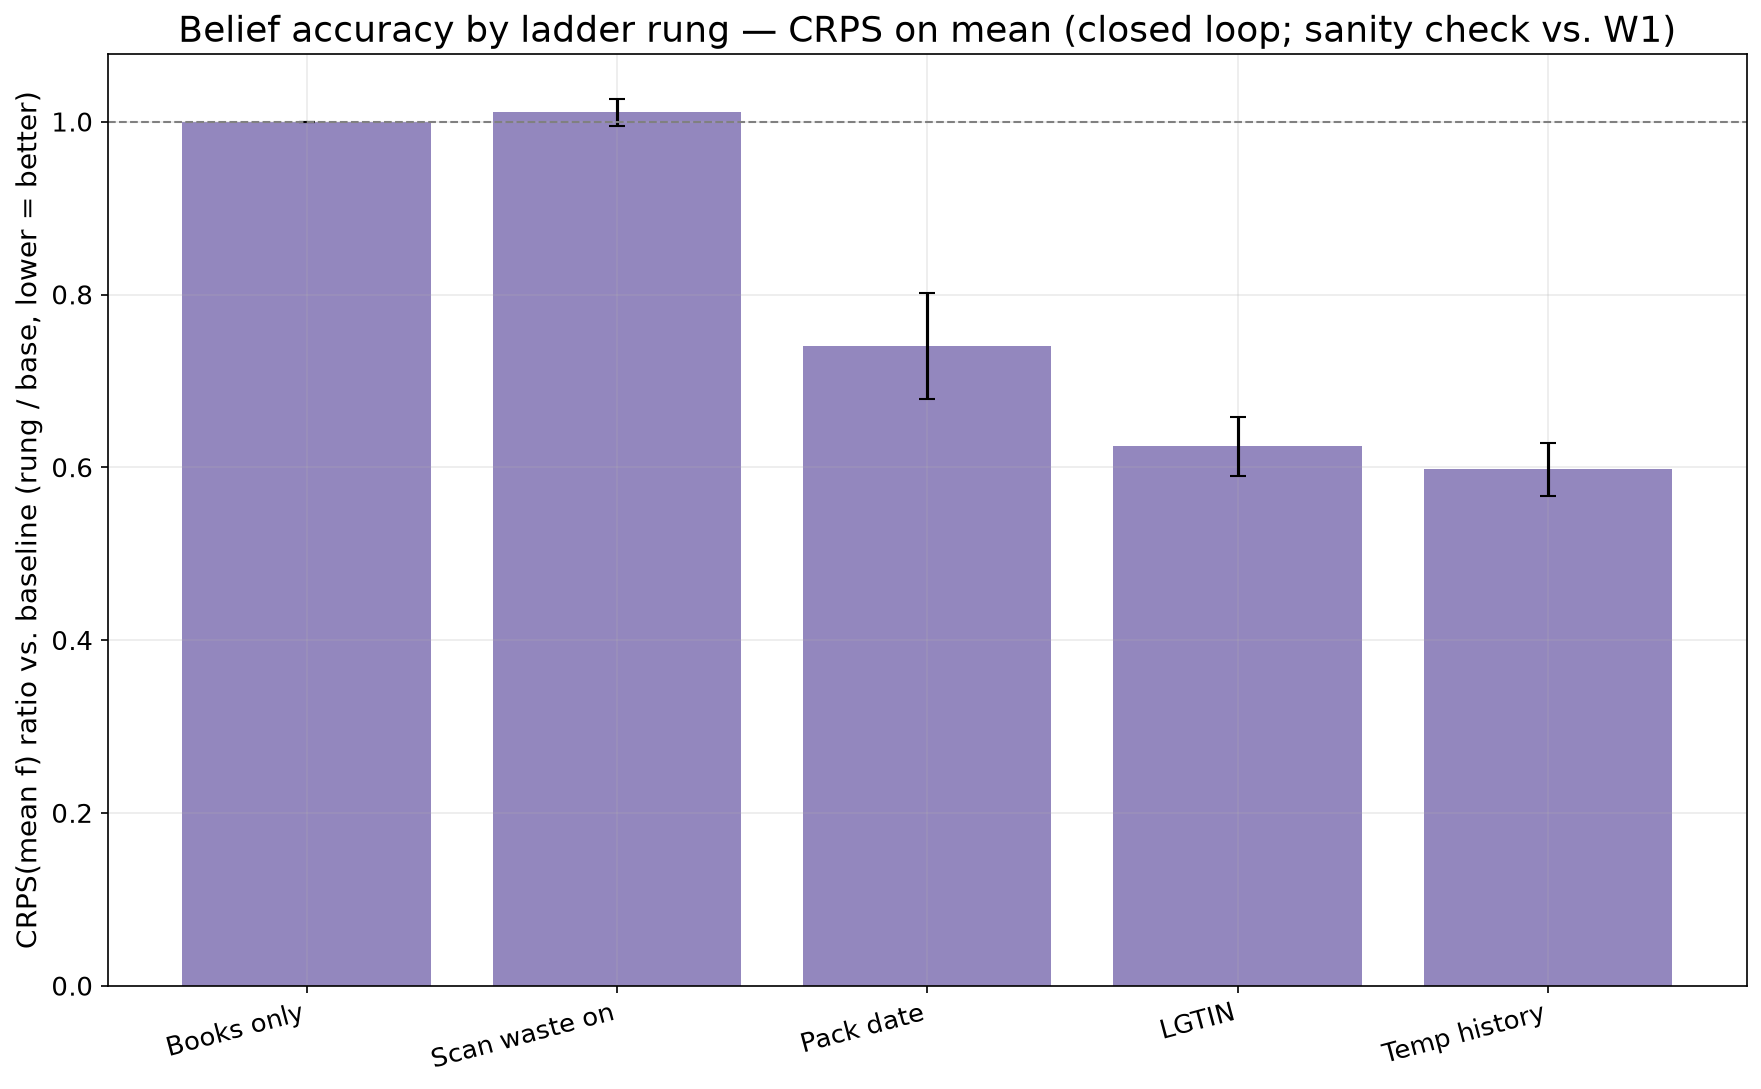

,crps_ratio_mean,crps_ratio_ci95
rung,,
Books only,1.000000,0.000000
Scan waste on,1.010740,0.015957
Pack date,0.740534,0.061176
LGTIN,0.624244,0.033833
Temp history,0.597683,0.030943


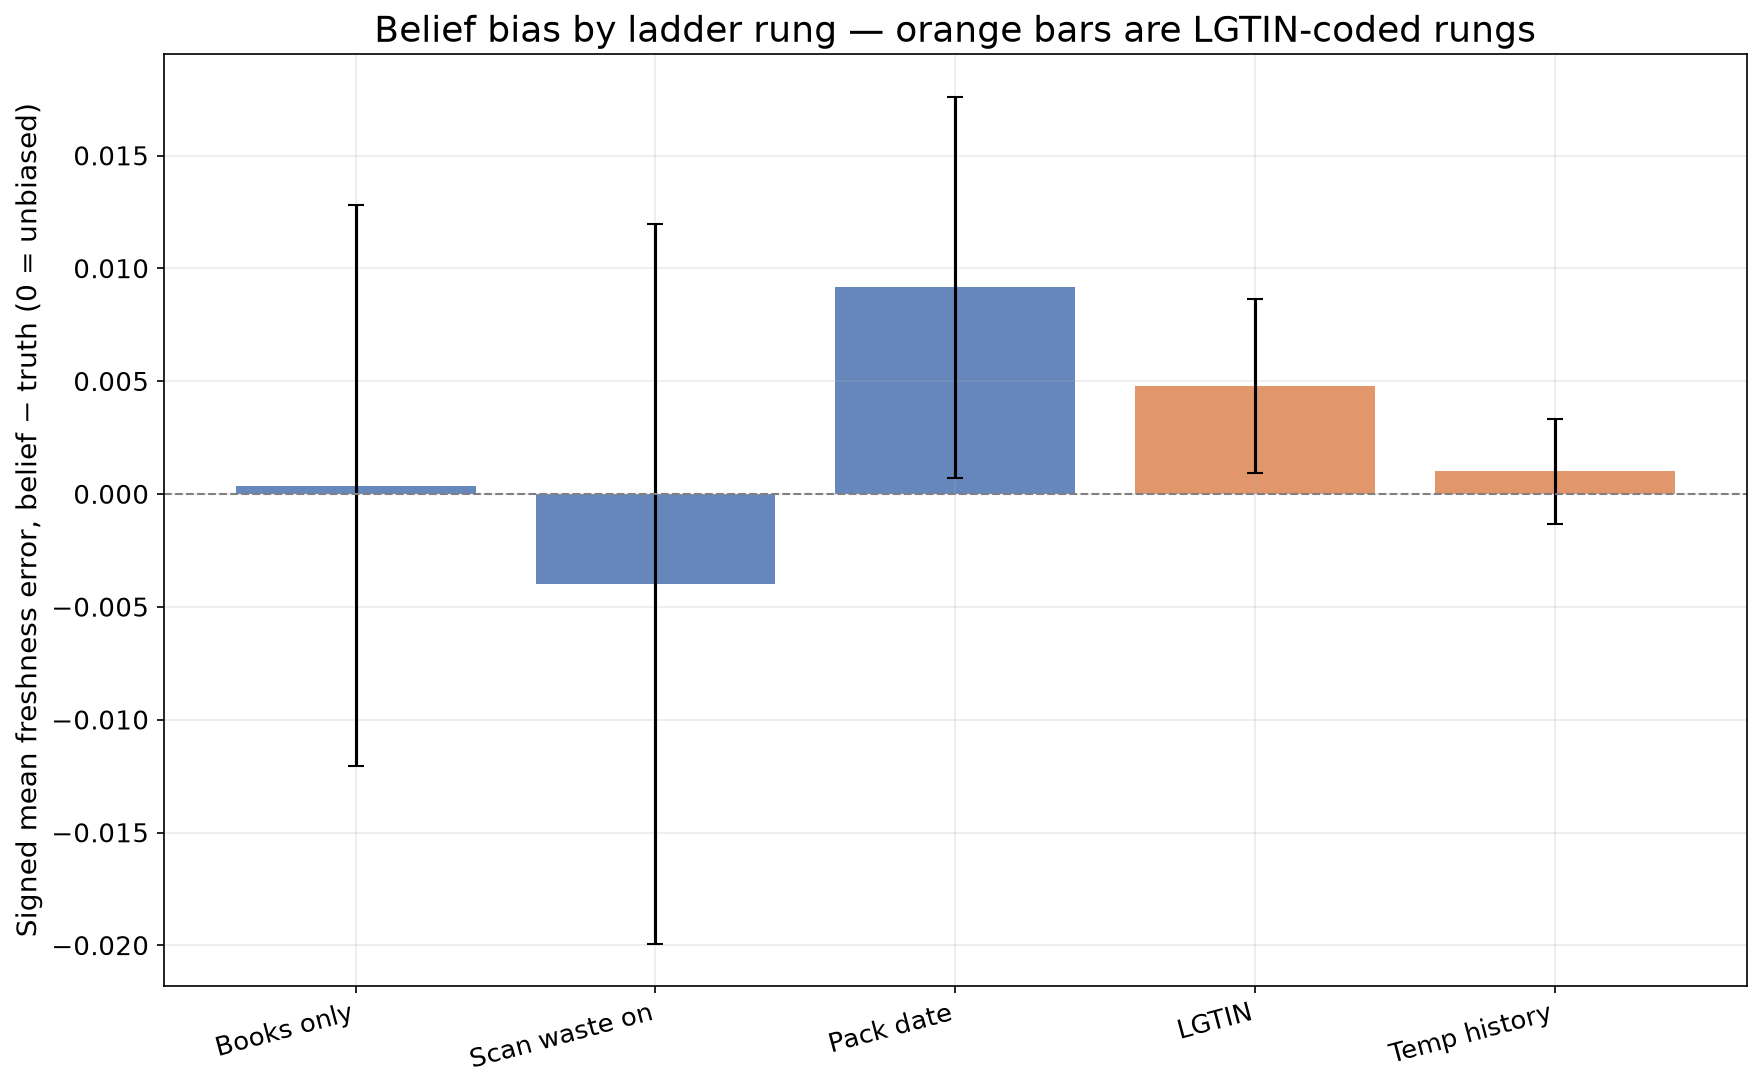

,code_type,mean_f_error,sem,ci95
Books only,upc,0.000377,0.006352,0.012450
Scan waste on,upc,-0.003981,0.008132,0.015939
Pack date,upc,0.009167,0.004308,0.008444
LGTIN,lgtin,0.004795,0.001965,0.003852
Temp history,lgtin,0.001007,0.001180,0.002313


In [14]:
def bar_chart(mean, ci, color, ylabel, title, out_name):
    fig, ax = plt.subplots(figsize=blog_figsize(BLOG_ASPECT_STANDARD))
    x = np.arange(len(LADDER_ORDER))
    ax.bar(x, mean[LADDER_ORDER], yerr=ci[LADDER_ORDER], capsize=4, color=color, alpha=0.85)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(LADDER_ORDER, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    save_blog_fig(fig, FIG_DIR / out_name)
    plt.show()


piv_crps = appendix_df.pivot_table(index="seed", columns="rung", values="crps_mean_f")[LADDER_ORDER]
crps_ratio = piv_crps.div(piv_crps["Books only"], axis=0)
crps_mean, crps_ci = mean_ci(crps_ratio)

bar_chart(crps_mean, crps_ci, PURPLE,
          "CRPS(mean f) ratio vs. baseline (rung / base, lower = better)",
          "Belief accuracy by ladder rung — CRPS on mean (closed loop; sanity check vs. W1)",
          BLOG_FIG_APPENDIX_CRPS_RATIO)
display(pd.DataFrame({
    "crps_ratio_mean": crps_mean[LADDER_ORDER],
    "crps_ratio_ci95": crps_ci[LADDER_ORDER],
}))

piv_bias = appendix_df.pivot_table(index="seed", columns="rung", values="mean_f_error")[LADDER_ORDER]
combos_bias = {label: ch["code_type"] for label, ch in LADDER}
bias_mean = piv_bias.mean()
bias_sem = piv_bias.std(ddof=1) / np.sqrt(len(piv_bias))
colors_bias = [ORANGE if combos_bias[l] == "lgtin" else BLUE for l in LADDER_ORDER]

fig, ax = plt.subplots(figsize=blog_figsize(BLOG_ASPECT_STANDARD))
x = np.arange(len(LADDER_ORDER))
ax.bar(x, bias_mean[LADDER_ORDER], yerr=1.96 * bias_sem[LADDER_ORDER], capsize=4, color=colors_bias, alpha=0.85)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(LADDER_ORDER, rotation=15, ha="right")
ax.set_ylabel("Signed mean freshness error, belief − truth (0 = unbiased)")
ax.set_title("Belief bias by ladder rung — orange bars are LGTIN-coded rungs")
fig.tight_layout()
save_blog_fig(fig, FIG_DIR / BLOG_FIG_APPENDIX_SIGNED_BIAS)
plt.show()

display(pd.DataFrame({
    "code_type": [combos_bias[l] for l in LADDER_ORDER],
    "mean_f_error": bias_mean[LADDER_ORDER],
    "sem": bias_sem[LADDER_ORDER],
    "ci95": 1.96 * bias_sem[LADDER_ORDER],
}, index=LADDER_ORDER))


**Read on the bias chart:** LGTIN-coded rungs (orange) cluster at a consistent positive
bias (belief overestimates freshness); UPC-coded rungs (blue) sit close to zero.
Flagged as a real, reproducible pattern worth investigating further — not resolved
here, not currently claimed in the post.

## Can you do better?

No new figure here — the reader-facing challenge harness lives in
[`notebooks/19_build_your_own_controller.ipynb`](19_build_your_own_controller.ipynb),
kept as its own dedicated notebook and linked directly from the post.